# Installing the package

Uncomment this line to download the package. For best results, install PyVaR in a fresh Python environment to avoid conflicts with existing packages.

In [1]:
#pip install git+https://github.com/Alessandro-Dodon/pyvar.git#subdirectory=package

---

## Notebook Overview

This notebook is dedicated to **time-varying volatility models** for portfolio risk. Here, we still work at the **portfolio level**, but move beyond the assumption of constant risk.

This approach enables more responsive and realistic VaR estimates, which are critical for managing portfolios in fast-changing market conditions.

We will experiment with four time-varying correlation models:

- The classic **Exponentially Weighted Moving Average (EWMA)**
- The **Moving Average (MA)**
- A **Rolling Principal Component Analysis (PCA)**
- The **Ledoit-Wolf (LW) shrinkage estimator**

These models provide a range of methods to estimate evolving correlations in a portfolio context.


### Packages

We begin by importing the `pyvar` package along with other necessary libraries for data handling, analysis, and visualization. Ensure all required packages are installed in your environment before proceeding.

In [2]:
import pyvar as pv

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf

---

### Creating a Portfolio 

Our package provides simple functions to automatically build your portfolio: prices are downloaded from Yahoo Finance, you specify the number of shares, and optionally convert everything to your base currency (CHF in our case). Those are particularly useful to check common problems like missing values, stability of the VCV matrix etc.

Our example portfolio follows a stylized global equity strategy:  
- Long positions in broad market, regional, and sector ETFs (VT, SPY, VGK, EWJ, VWO)  
- Exposure to leading firms in tech, healthcare, and consumer sectors (AAPL, JNJ, PG, UNH, NVS)  
- A small short position in industrials (XLI) to hedge against cyclical downturns

We assume a **buy-and-hold** or "lazy portfolio" strategy. No active trading or rebalancing is considered. If the portfolio composition changes, all subsequent VaR and ES metrics must be recomputed from that point onward.

In [4]:
# Define shares — globally diversified portfolio
shares = pd.Series({
    "VT": 120,     # Global equity ETF
    "SPY": 80,     # US large-cap ETF
    "VGK": 60,     # Europe ETF
    "EWJ": 40,     # Japan ETF
    "VWO": 60,     # Emerging Markets ETF
    "AAPL": 50,    # Apple — tech
    "JNJ": 50,     # Johnson & Johnson — healthcare
    "PG": 40,      # Procter & Gamble — consumer staples
    "UNH": 40,     # UnitedHealth — healthcare
    "NVS": 30,     # Novartis — Swiss healthcare
    "XLI": -30     # US industrials sector ETF — short hedge
})

# Download prices and convert to base currency
tickers = shares.index.tolist()
raw_prices = pv.get_raw_prices(tickers, start="2023-01-01", end="2025-01-01")
prices_chf = pv.convert_to_base_currency(raw_prices, base_currency="CHF")

# Compute monetary position values over time
portfolio_matrix = pv.create_portfolio(prices_chf, shares)

# Compute portfolio returns and statistics
portfolio_returns = pv.compute_returns(portfolio_matrix)

[currency detection] AAPL: USD
[currency detection] EWJ: USD
[currency detection] JNJ: USD
[currency detection] NVS: USD
[currency detection] PG: USD
[currency detection] SPY: USD
[currency detection] UNH: USD
[currency detection] VGK: USD
[currency detection] VT: USD
[currency detection] VWO: USD
[currency detection] XLI: USD
[fx download] Downloading FX pairs: CHFUSD=X
[conversion] AAPL: USD → CHF via CHFUSD=X
[conversion] EWJ: USD → CHF via CHFUSD=X
[conversion] JNJ: USD → CHF via CHFUSD=X
[conversion] NVS: USD → CHF via CHFUSD=X
[conversion] PG: USD → CHF via CHFUSD=X
[conversion] SPY: USD → CHF via CHFUSD=X
[conversion] UNH: USD → CHF via CHFUSD=X
[conversion] VGK: USD → CHF via CHFUSD=X
[conversion] VT: USD → CHF via CHFUSD=X
[conversion] VWO: USD → CHF via CHFUSD=X
[conversion] XLI: USD → CHF via CHFUSD=X


In [5]:
prices_chf.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,231.426704,59.223917,128.896222,85.194986,149.932985,537.042054,449.589076,56.368558,106.685961,40.067612,119.804971
2024-12-26,232.407133,59.973532,128.793635,85.328432,151.175409,537.645712,454.555311,56.578238,106.923679,40.011427,120.021037
2024-12-27,229.196950,60.393619,128.250552,85.270424,150.528611,531.678524,453.261519,56.360245,106.023655,39.845030,119.058198
2024-12-30,226.896698,60.081229,127.153121,84.627656,148.847330,527.330344,452.791238,56.172813,105.341614,39.625007,118.246502
2024-12-31,225.645051,60.120737,128.487744,84.741616,149.578046,526.227574,451.761624,56.268884,105.263231,39.623541,118.286434


In [6]:
# Compute latest portfolio value and weights
latest_prices = prices_chf.iloc[-1]
portfolio_value_chf = (shares * latest_prices).sum()
weights = (shares * latest_prices) / portfolio_value_chf

# Print final portfolio value and weights
print(f"\nFinal portfolio value in CHF: {portfolio_value_chf:,.2f}\n")
print("Portfolio weights (based on latest prices):")
print(weights.round(4).sort_values(ascending=False))


Final portfolio value in CHF: 103,642.05

Portfolio weights (based on latest prices):
SPY     0.4062
UNH     0.1744
VT      0.1219
AAPL    0.1089
JNJ     0.0620
PG      0.0577
VGK     0.0326
NVS     0.0245
EWJ     0.0232
VWO     0.0229
XLI    -0.0342
dtype: float64


A quick way to observe the correlations of our portfolio!


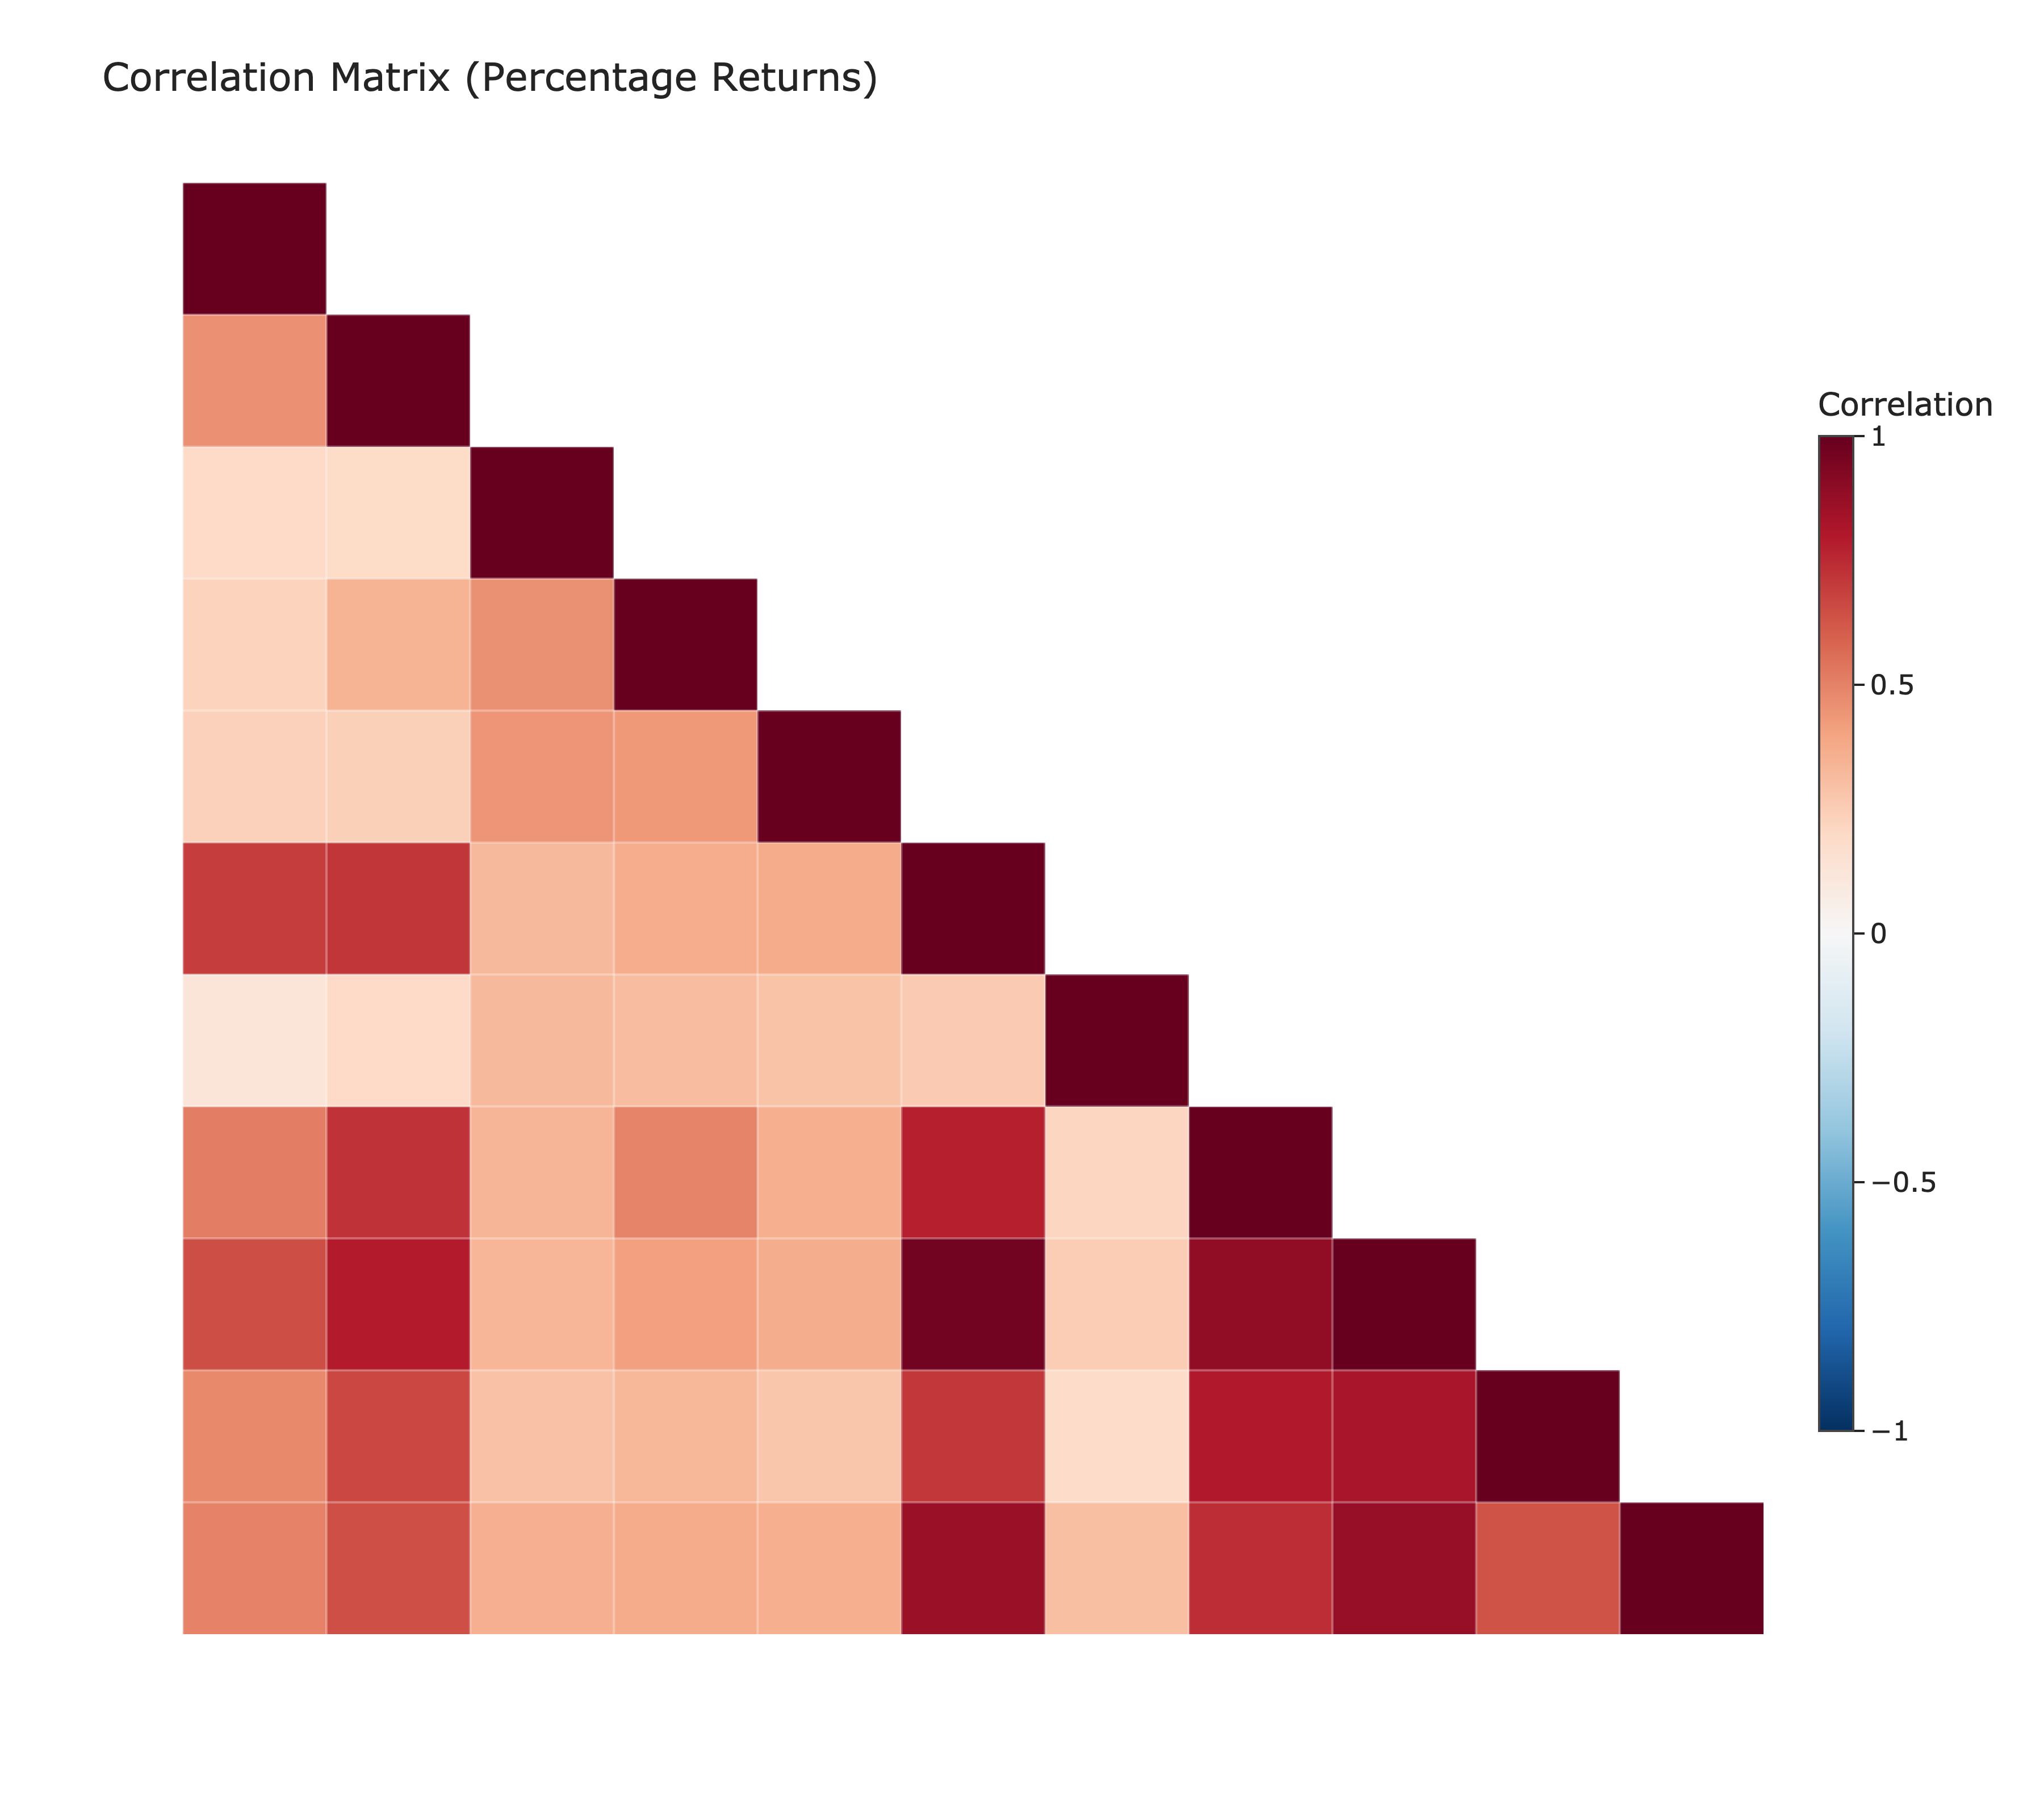

In [7]:
pv.plot_correlation_matrix(portfolio_matrix, interactive=False)

In [8]:
portfolio_matrix.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,11571.335187,2368.956681,6444.811080,2555.849567,5997.319403,42963.364293,17983.563021,3382.113458,12802.315271,2404.056728,-3594.149135
2024-12-26,11620.356641,2398.941292,6439.681748,2559.852947,6047.016349,43011.656968,18182.212443,3394.694253,12830.841531,2400.685620,-3600.631118
2024-12-27,11459.847524,2415.744774,6412.527622,2558.112730,6021.144452,42534.281923,18130.460765,3381.614726,12722.838569,2390.701805,-3571.745932
2024-12-30,11344.834895,2403.249158,6357.656070,2538.829686,5953.893188,42186.427518,18111.649528,3370.368783,12640.993732,2377.500427,-3547.395061
2024-12-31,11282.252544,2404.829490,6424.387178,2542.248472,5983.121833,42098.205949,18070.464940,3376.133050,12631.587685,2377.412469,-3548.593034


In [9]:
portfolio_returns.tail()

,AAPL,EWJ,JNJ,NVS,PG,SPY,UNH,VGK,VT,VWO,XLI
Date,,,,,,,,,,,
2024-12-24,0.017617,0.005464,0.010086,0.005047,0.011036,0.017252,0.005592,0.011608,0.014032,0.010130,0.013929
2024-12-26,0.004236,0.012657,-0.000796,0.001566,0.008287,0.001124,0.011046,0.003720,0.002228,-0.001402,0.001803
2024-12-27,-0.013813,0.007005,-0.004217,-0.000680,-0.004278,-0.011099,-0.002846,-0.003853,-0.008417,-0.004159,-0.008022
2024-12-30,-0.010036,-0.005173,-0.008557,-0.007538,-0.011169,-0.008178,-0.001038,-0.003326,-0.006433,-0.005522,-0.006818
2024-12-31,-0.005516,0.000658,0.010496,0.001347,0.004909,-0.002091,-0.002274,0.001710,-0.000744,-0.000037,0.000338


If you want to **save the DataFrame shown above**, use:

```python
portfolio_returns.to_csv("portfolio_returns.csv")
```

If you want to **import your own CSV**, make sure the first column contains dates and use:

```python
df = pd.read_csv("your_file.csv", index_col=0, parse_dates=True)
```

This ensures:
- The first column becomes the date index
- Dates are properly parsed for the analysis

Note: You are responsible for data cleaning and pre-processing when using your own files. Our data-download functions will print warnings if there are issues, but they do not perform automatic cleaning.

---

### MA Correlation 

This model computes the portfolio covariance matrix using a simple **rolling window** of past returns. At each time $t$, we estimate:

$$
\Sigma_t = \text{Cov}(r_{t-h+1}, \dots, r_{t})
$$

The portfolio volatility is:

$$
\sigma_{p,t} = \sqrt{w_t^\top \Sigma_t w_t}
$$

Then, the Value-at-Risk is:

$$
\text{VaR}_t = z_\alpha \cdot \sigma_{p,t} \cdot \text{PortfolioValue}_t
$$

We support two estimation modes:
- **Parametric**: use $z_\alpha$ from the Normal distribution.
- **Empirical**: extract standardized residuals $z_t = r_t / \sigma_{p,t}$ and compute the quantile directly from their empirical distribution.

This is the most basic dynamic correlation method and acts as a benchmark for more advanced models.


In [10]:
# General parameter
confidence_level = 0.99

In [11]:
# Run RiskMetrics Correlation VaR
result_ma_correlation = pv.ma_correlation_var(portfolio_matrix, distribution="empirical", confidence_level=confidence_level, window_size=60) 

# ES RiskMetrics
result_ma_correlation = pv.correlation_es(result_ma_correlation, confidence_level=confidence_level)


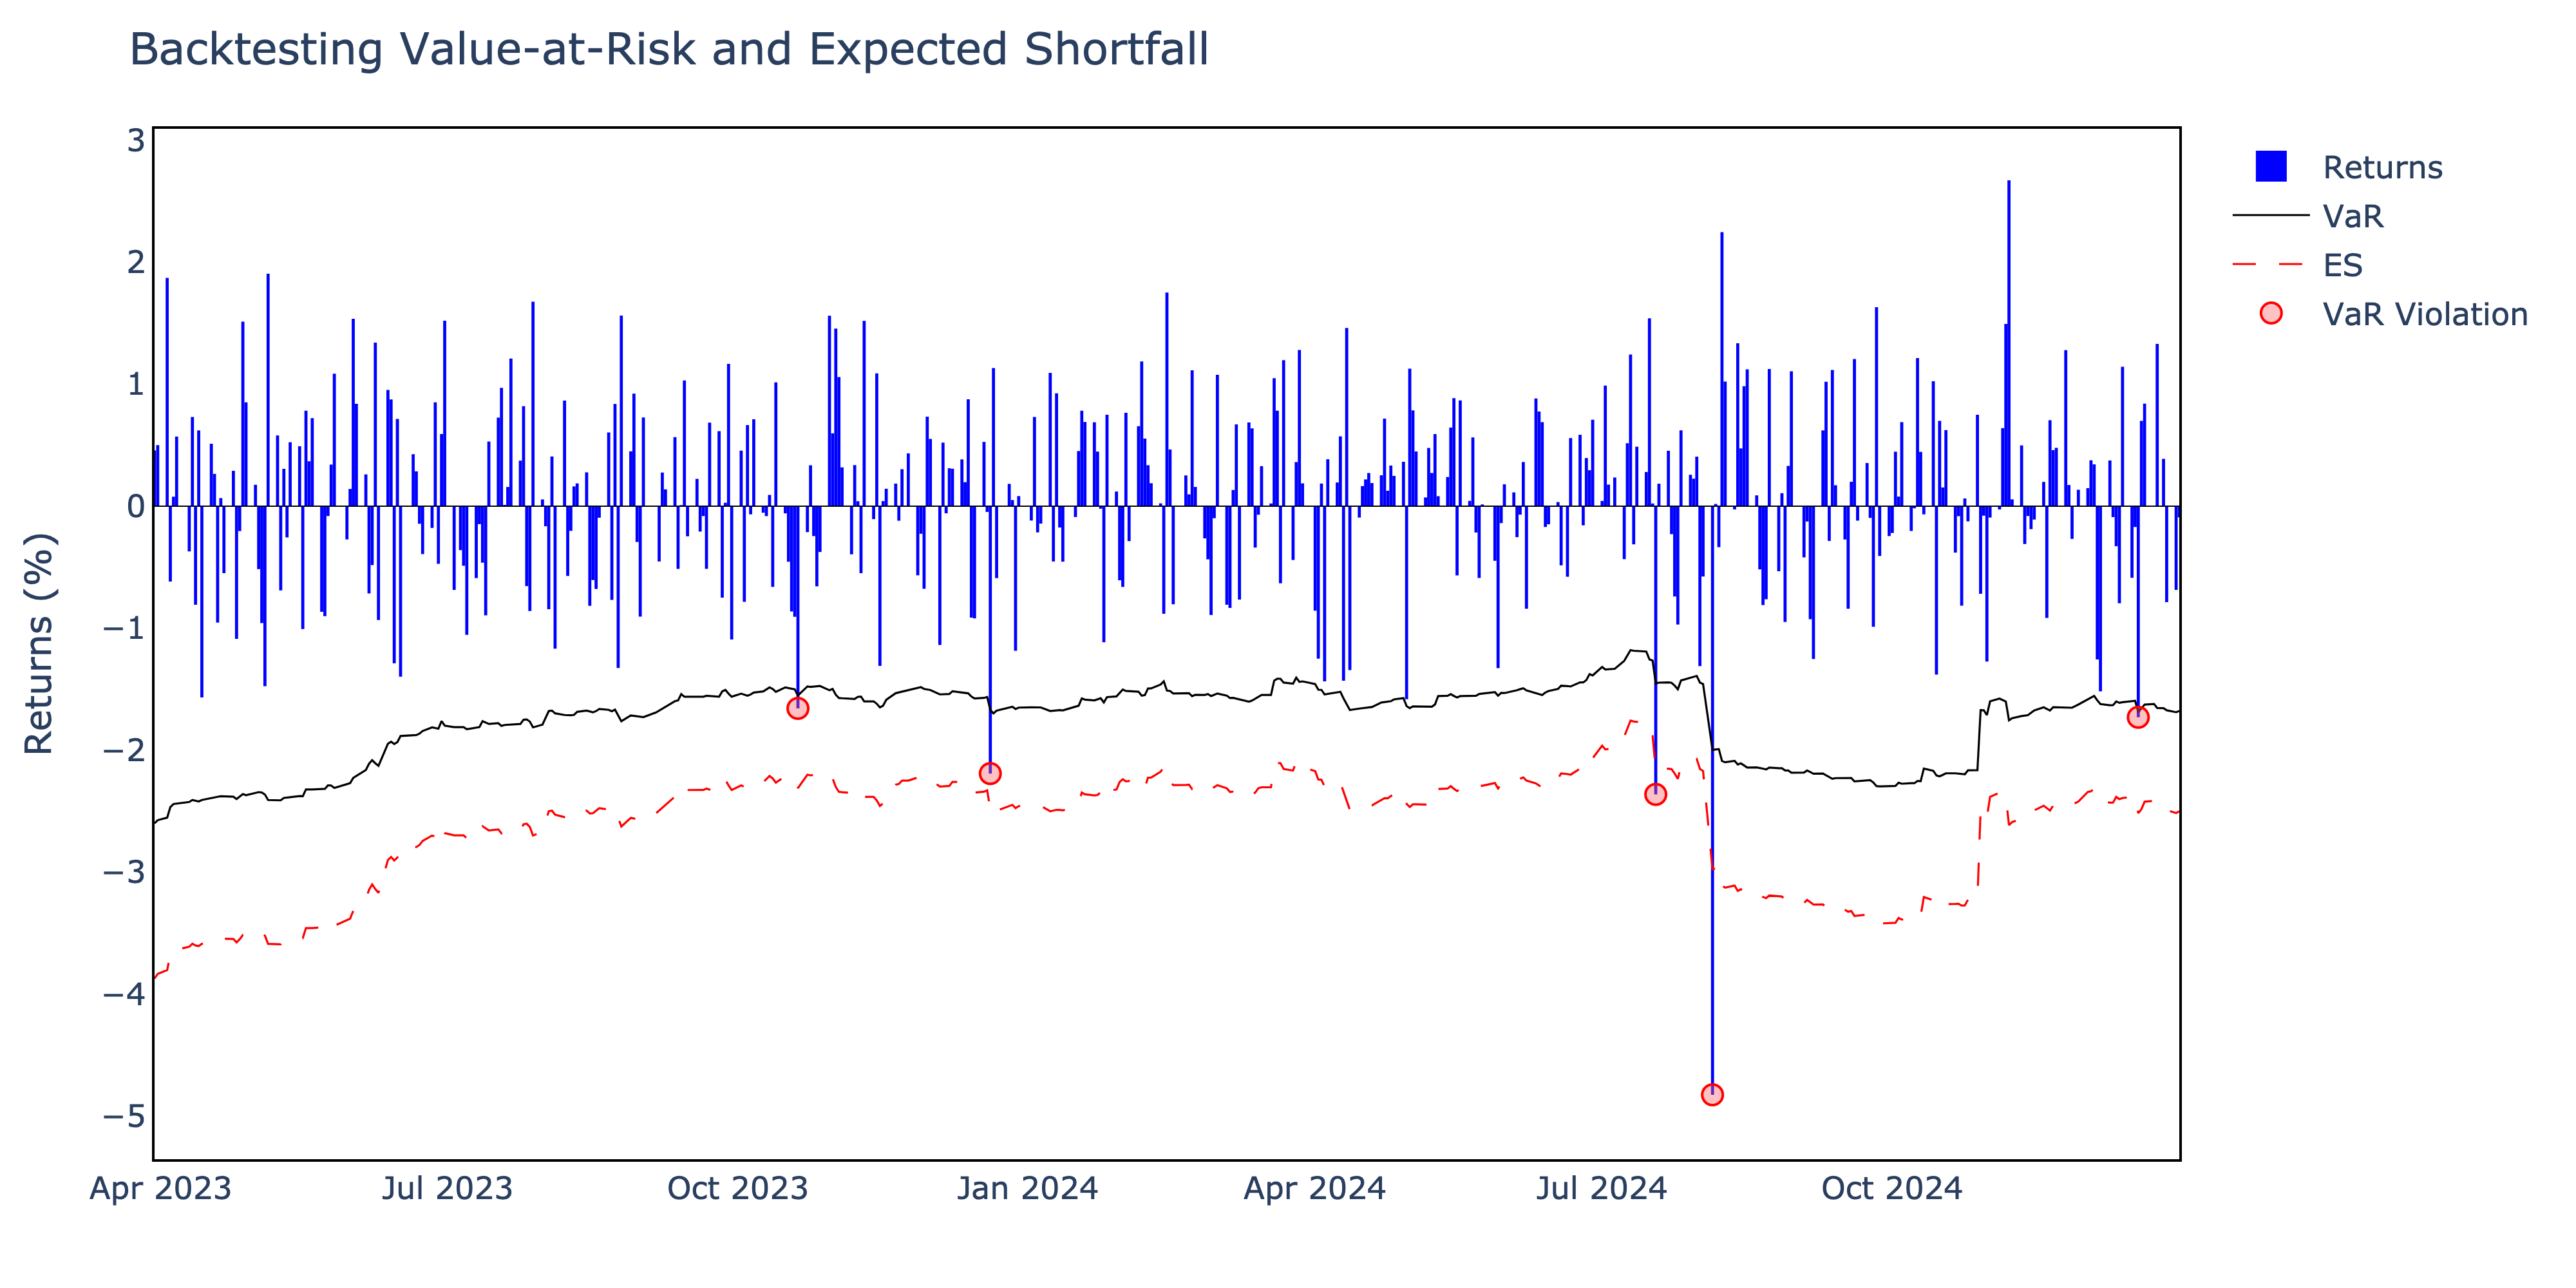

In [12]:
# Plot RiskMetrics model results
pv.plot_backtest(result_ma_correlation, interactive=False)


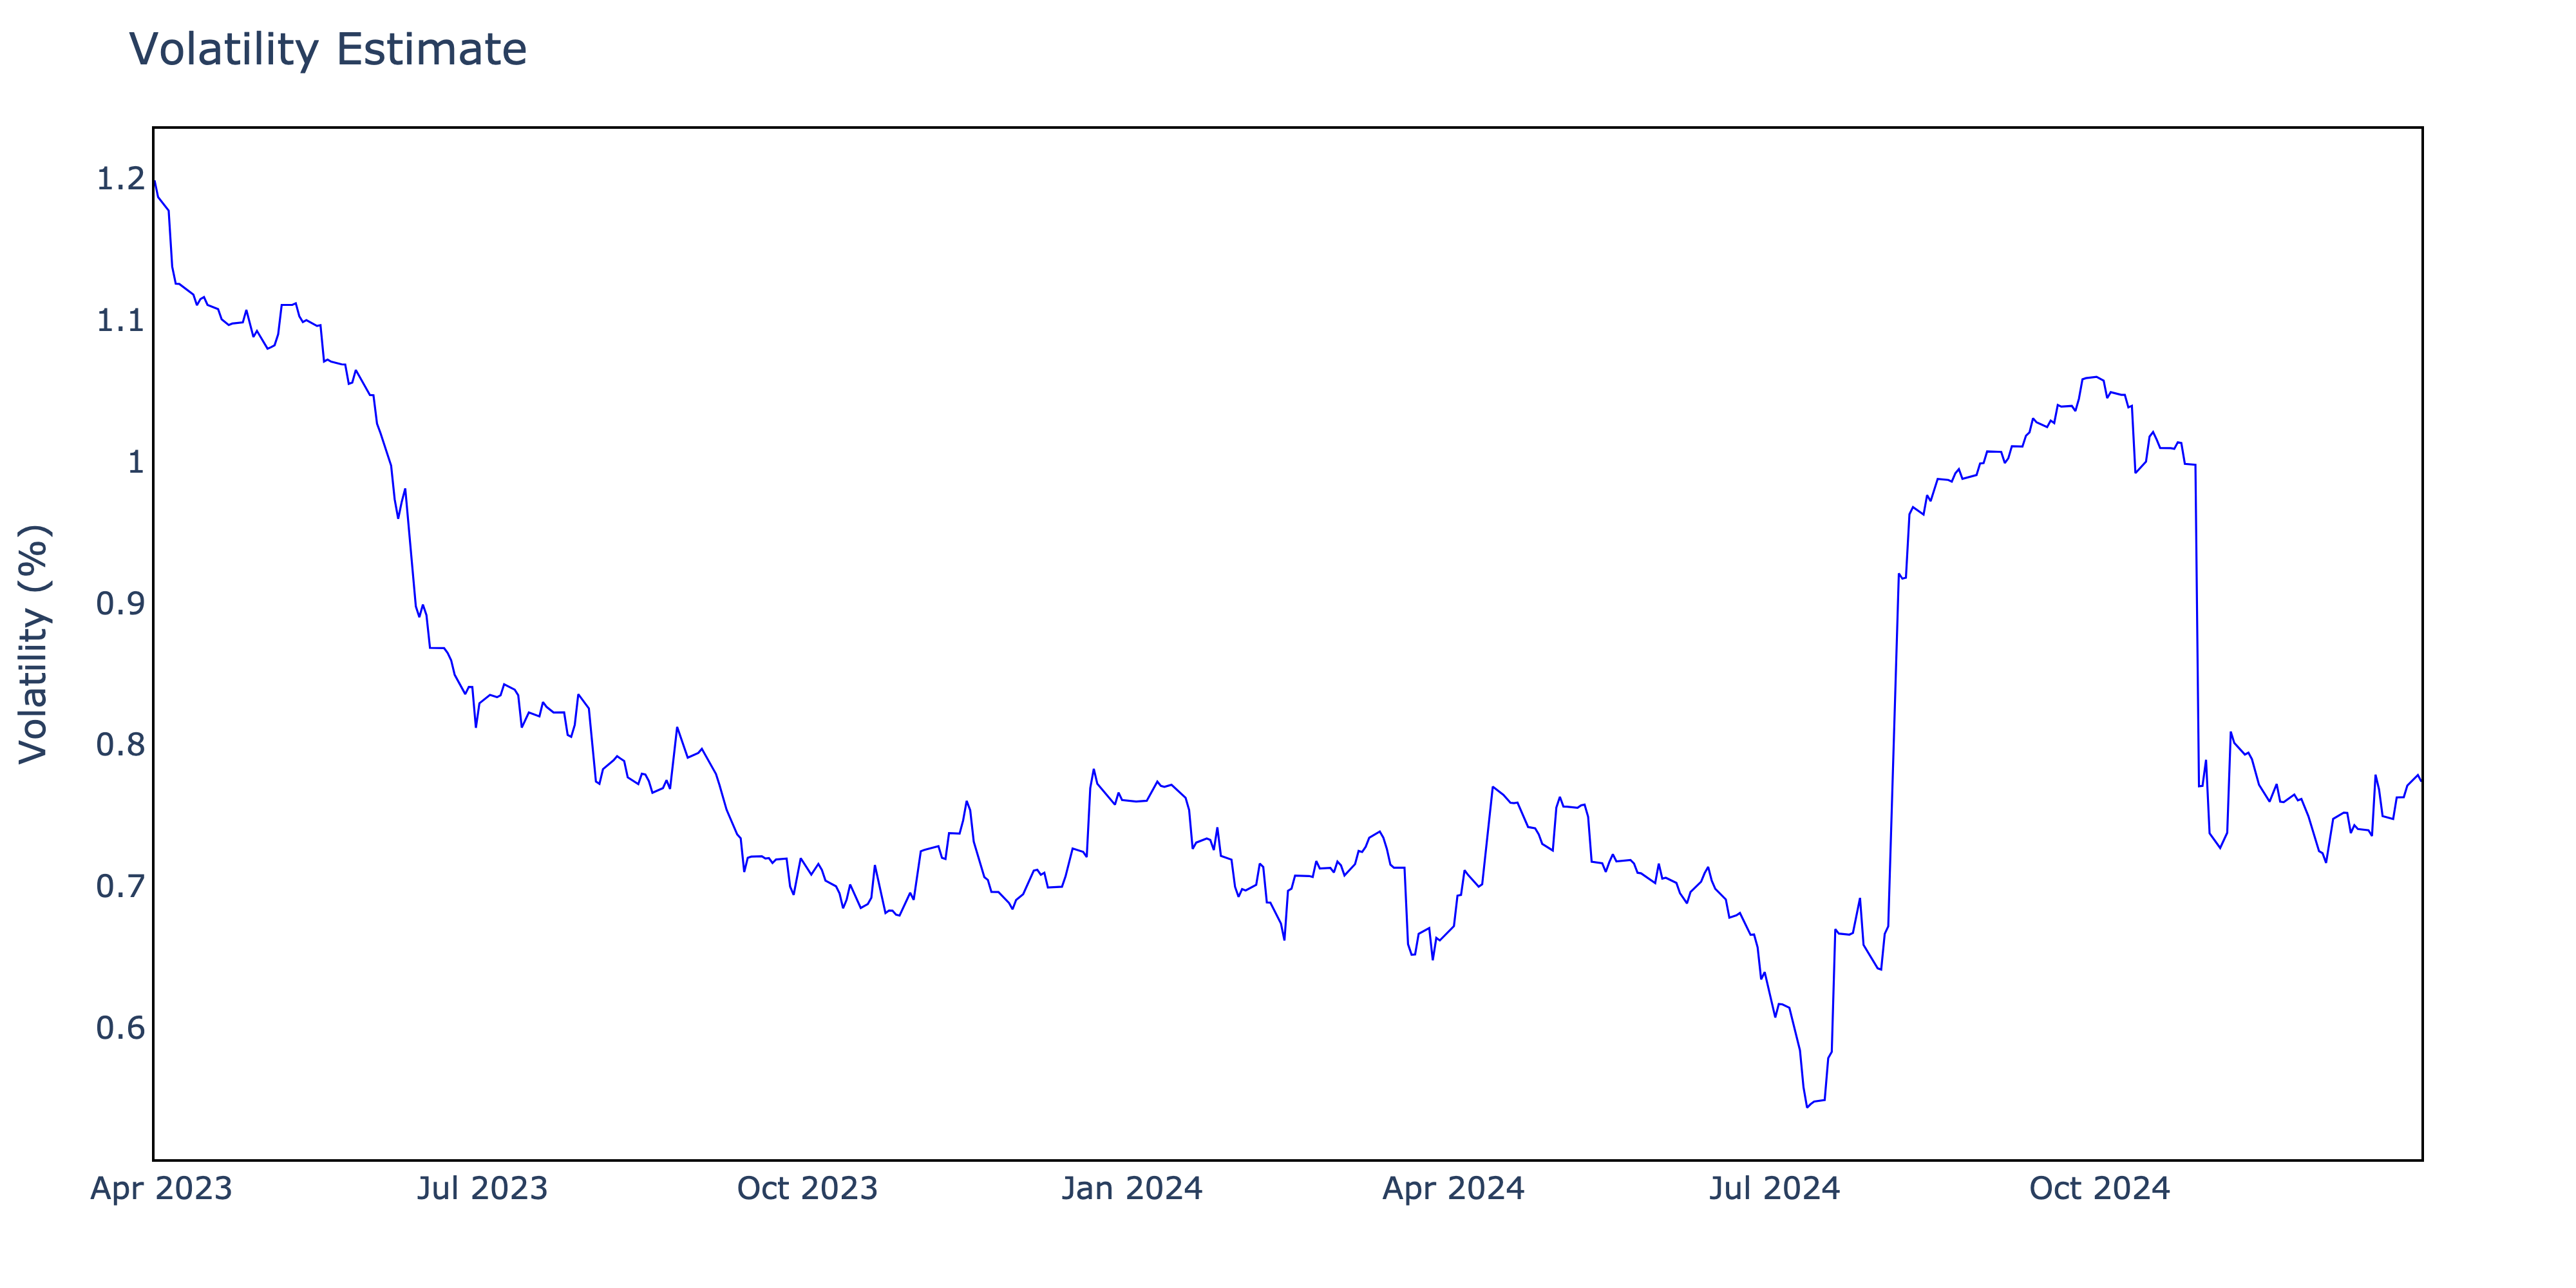

In [13]:
# Plot portfolio volatility 
pv.plot_volatility(result_ma_correlation["Volatility"], interactive=False)

#### Backtesting MA

With the introduction of **time-varying correlation models**, even the most basic approach—**rolling MA covariance**—yields strong results. 

Remarkably, we now observe **fully successful backtesting** across all three statistical tests, even at the **portfolio level**, highlighting the effectiveness of dynamic risk modeling over static assumptions.

In [14]:
# Count violations
ma_corr_violations, ma_corr_violation_rate = pv.count_violations(result_ma_correlation)

# Kupiec Test (Unconditional Coverage)
ma_corr_kupiec = pv.kupiec_test(
    total_violations=ma_corr_violations,
    total_days=len(result_ma_correlation),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
ma_corr_christoffersen = pv.christoffersen_test(result_ma_correlation)

# Joint Test (Conditional Coverage)
ma_corr_joint = pv.joint_lr_test(
    LR_uc=ma_corr_kupiec["LR_uc"],
    LR_c=ma_corr_christoffersen["LR_c"]
)

In [15]:
# Summary output
print(f"\n--- MA Correlation VaR Backtesting Summary ---")
print(f"Total Violations     : {ma_corr_violations}")
print(f"Violation Rate       : {ma_corr_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {ma_corr_kupiec['LR_uc']:.4f}")
print(f"p-value             : {ma_corr_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {ma_corr_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {ma_corr_christoffersen['LR_c']:.4f}")
print(f"p-value             : {ma_corr_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {ma_corr_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {ma_corr_joint['LR_total']:.4f}")
print(f"p-value             : {ma_corr_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {ma_corr_joint['reject_null']}")



--- MA Correlation VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.13%

Kupiec Test (UC):
LR_uc               : 0.0738
p-value             : 0.7860
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1147
p-value             : 0.7349
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1884
p-value             : 0.9101
Reject Null (5%)    : False


---

### EWMA Correlation 

EWMA improves on MA by assigning **exponentially decaying weights** to past returns. The covariance matrix is updated recursively:

$$
\Sigma_t = \lambda \Sigma_{t-1} + (1 - \lambda) r_{t-1} r_{t-1}^\top
$$

This captures time-varying volatility and correlation more responsively than MA. The same VaR logic follows:

- Compute $\sigma_{p,t} = \sqrt{w_t^\top \Sigma_t w_t}$
- Multiply by $z_\alpha$ to obtain VaR

As with all our models, you can use either:
- **Parametric VaR** with Normal quantile
- **Empirical VaR**, using standardized residuals and empirical quantiles

This model is widely used in practice due to its simplicity and better responsiveness to recent market shocks.


In [16]:
# EWMA parameter
lambda_decay = 0.94 

In [17]:
# Run RiskMetrics Correlation VaR
result_ewma_correlation = pv.ewma_correlation_var(portfolio_matrix, distribution="empirical", lambda_decay=lambda_decay, confidence_level=confidence_level) 

# ES RiskMetrics
result_ewma_correlation = pv.correlation_es(result_ewma_correlation, confidence_level=confidence_level)


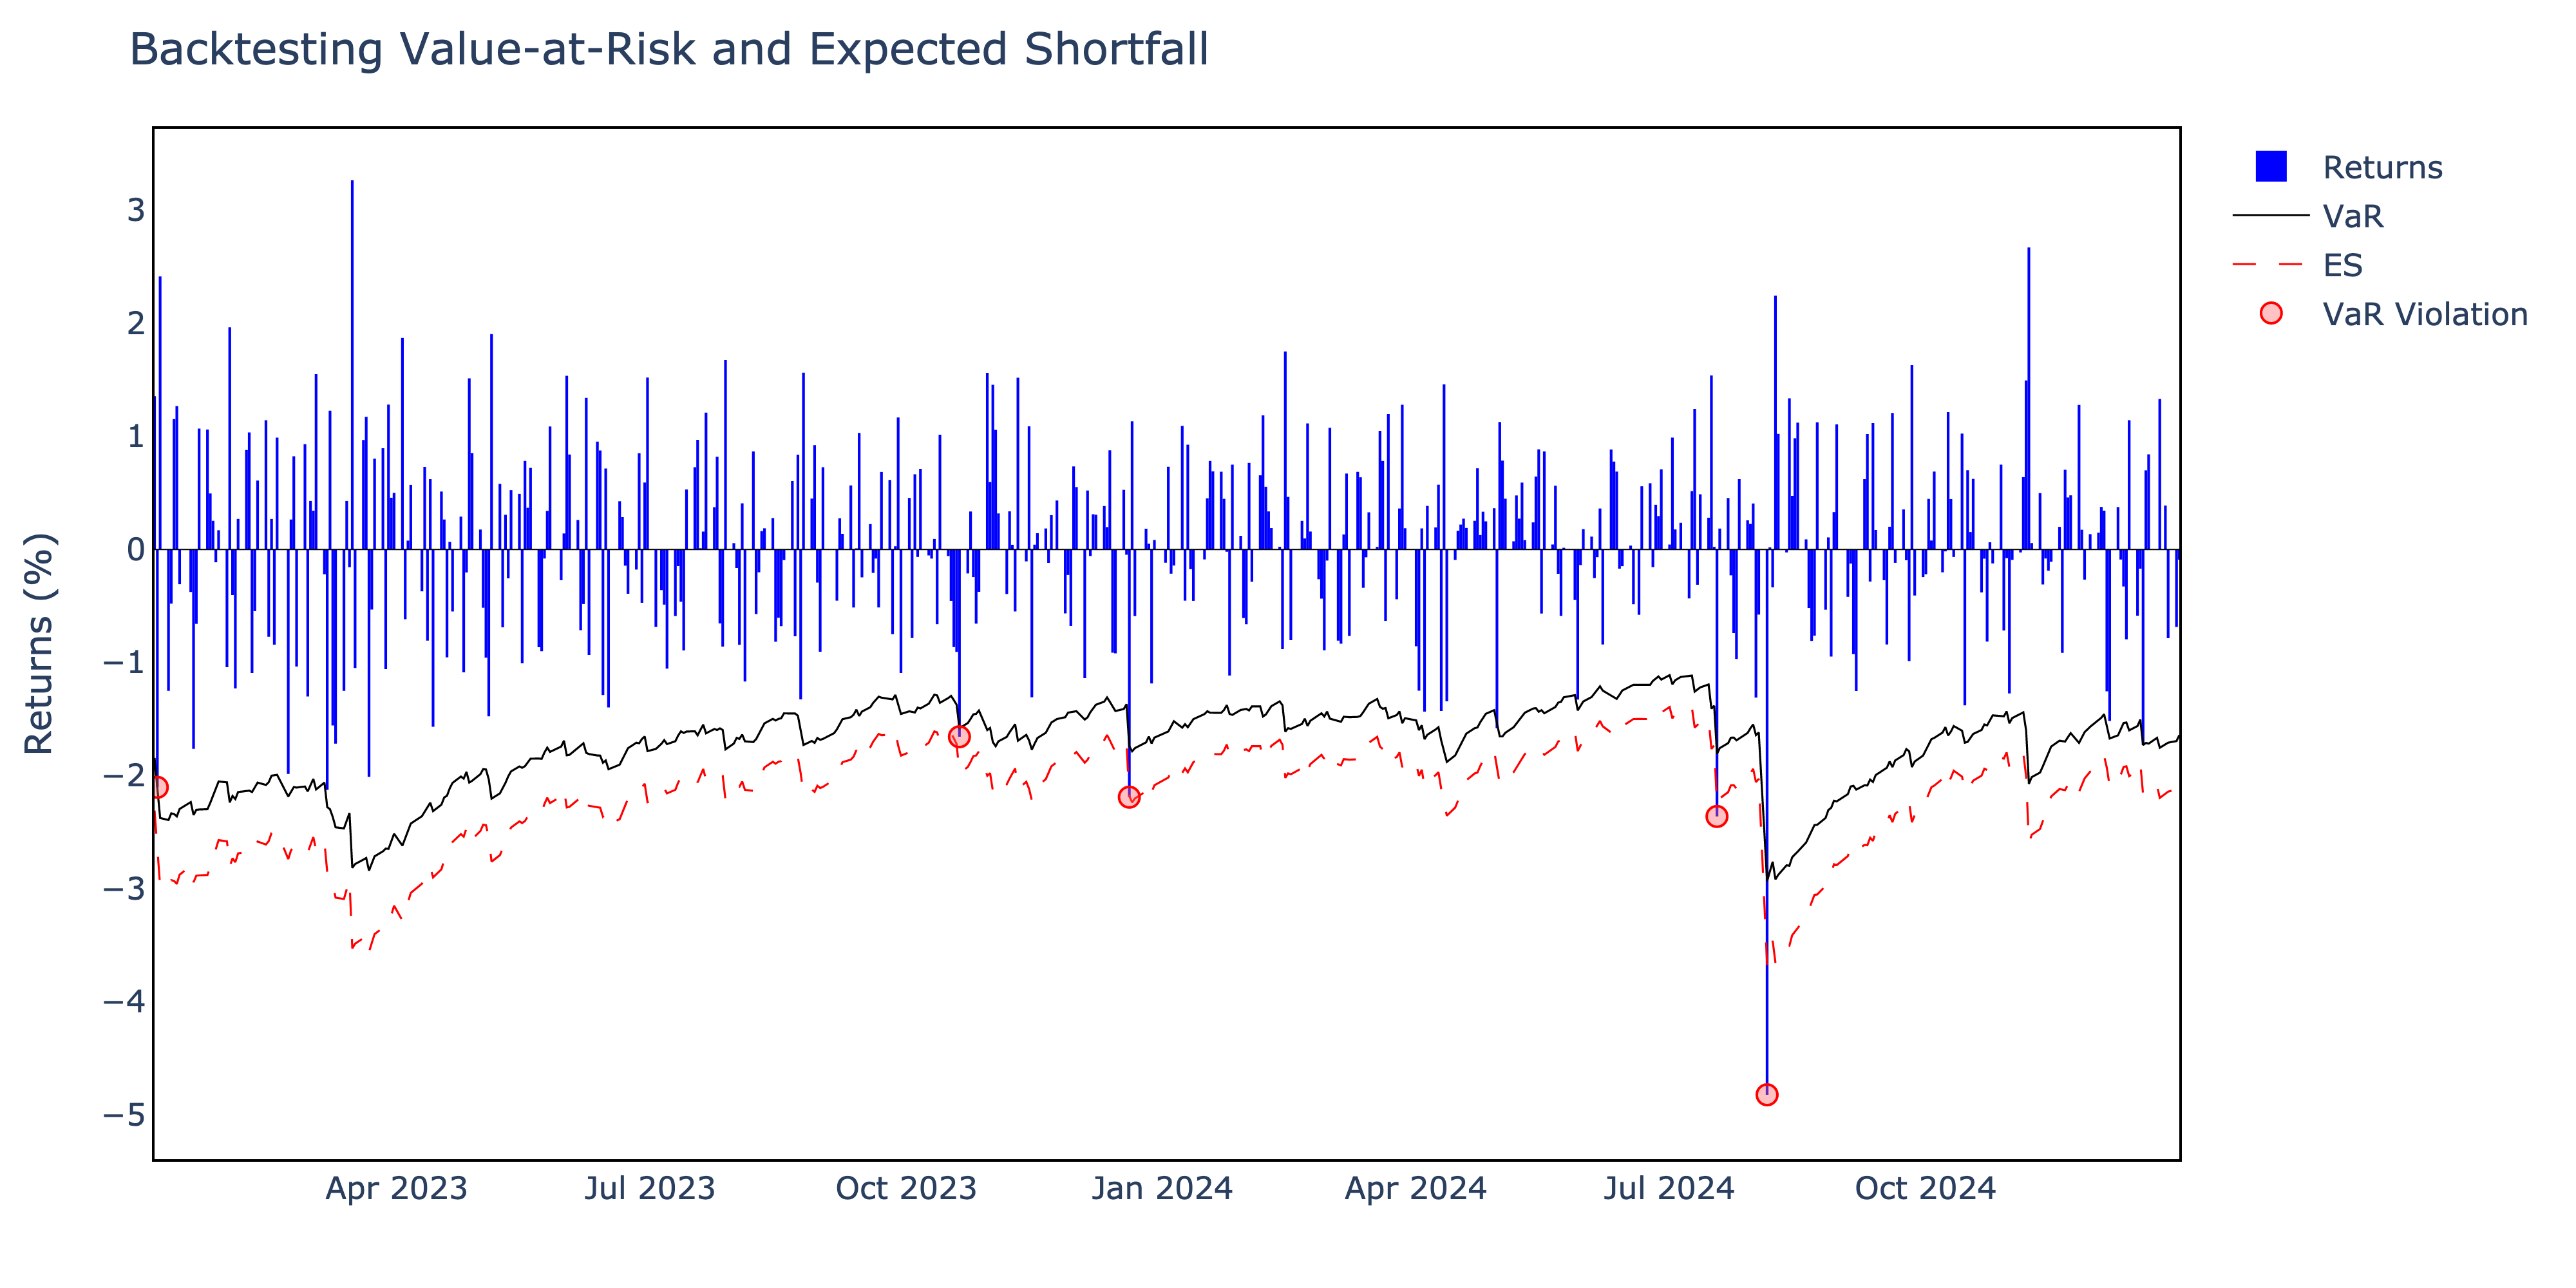

In [18]:
# Plot RiskMetrics model results
pv.plot_backtest(result_ewma_correlation, interactive=False)


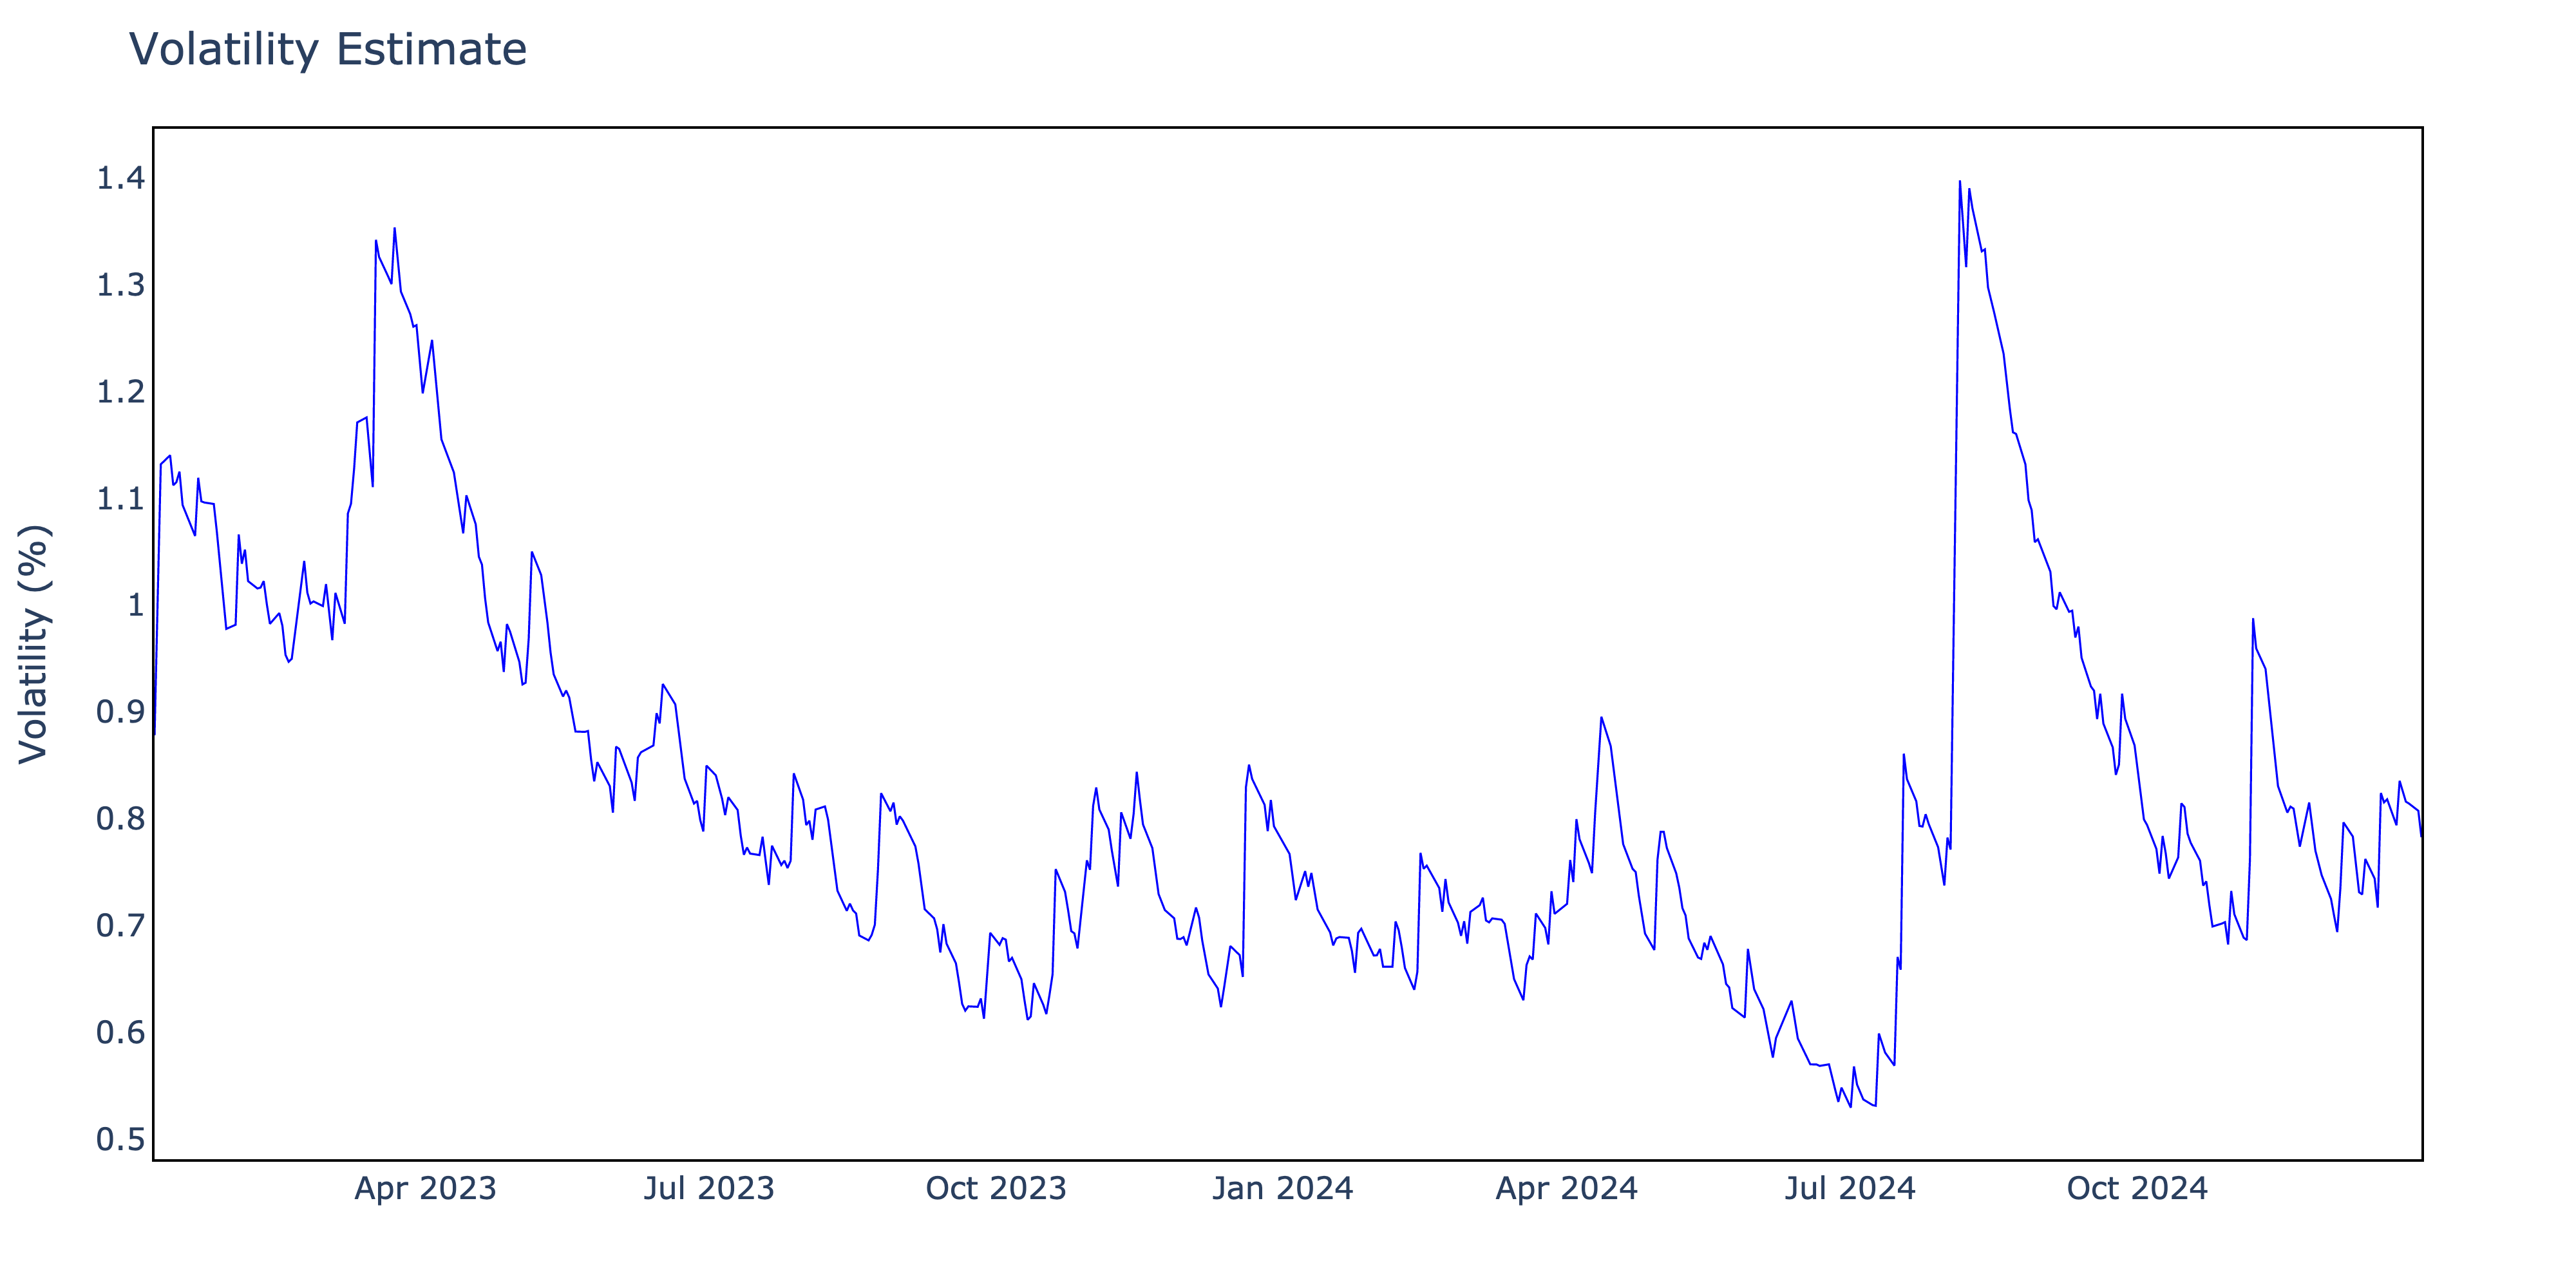

In [19]:
# Plot portfolio volatility 
pv.plot_volatility(result_ewma_correlation["Volatility"], interactive=False)

In [20]:
result_ewma_correlation.head()

,Returns,Volatility,Innovations,VaR,VaR Monetary,VaR Violation,ES,ES Monetary
2023-01-04,0.013557,0.008782,1.543672,0.018435,1489.639058,False,0.023101,1866.661993
2023-01-05,-0.021046,0.009955,-2.114082,0.020898,1652.972317,True,0.026187,2071.334383
2023-01-06,0.024151,0.011318,2.133877,0.023759,1924.450018,False,0.029773,2411.522232
2023-01-09,-0.012504,0.011403,-1.096588,0.023937,1914.410374,False,0.029995,2398.941586
2023-01-10,-0.004796,0.011122,-0.431189,0.023348,1858.311740,False,0.029257,2328.644565


#### Backtesting EWMA 

In [21]:
# Count violations
ewma_corr_violations, ewma_corr_violation_rate = pv.count_violations(result_ewma_correlation)

# Kupiec Test (Unconditional Coverage)
ewma_corr_kupiec = pv.kupiec_test(
    total_violations=ewma_corr_violations,
    total_days=len(result_ewma_correlation),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
ewma_corr_christoffersen = pv.christoffersen_test(result_ewma_correlation)

# Joint Test (Conditional Coverage)
ewma_corr_joint = pv.joint_lr_test(
    LR_uc=ewma_corr_kupiec["LR_uc"],
    LR_c=ewma_corr_christoffersen["LR_c"]
)

In [22]:
# Summary output
print(f"\n--- RiskMetrics Correlation VaR Backtesting Summary ---")
print(f"Total Violations     : {ewma_corr_violations}")
print(f"Violation Rate       : {ewma_corr_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {ewma_corr_kupiec['LR_uc']:.4f}")
print(f"p-value             : {ewma_corr_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {ewma_corr_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {ewma_corr_christoffersen['LR_c']:.4f}")
print(f"p-value             : {ewma_corr_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {ewma_corr_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {ewma_corr_joint['LR_total']:.4f}")
print(f"p-value             : {ewma_corr_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {ewma_corr_joint['reject_null']}")


--- RiskMetrics Correlation VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.00%

Kupiec Test (UC):
LR_uc               : 0.0000
p-value             : 0.9964
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1010
p-value             : 0.7506
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1010
p-value             : 0.9507
Reject Null (5%)    : False


---

### Rolling PCA Correlation 

This model reduces noise in the covariance matrix by applying **Principal Component Analysis (PCA)** to a rolling window of returns. Only the top $k$ components are retained to reconstruct a **low-rank covariance matrix**:

$$
\Sigma_t \approx V_t D_t V_t^\top
$$

Where:
- $D_t$ are the top $k$ eigenvalues
- $V_t$ are the corresponding eigenvectors

This is particularly effective in large portfolios where the sample covariance may be unstable.

As always:
- Compute $\sigma_{p,t}$ from the PCA-filtered $\Sigma_t$
- Apply either **Normal quantile** or **empirical quantile** for VaR

PCA introduces a structured form of shrinkage and dimension reduction.

Before applying PCA, it is useful to compute the **cumulative explained variance** of the components over a typical rolling window. This helps to make an informed choice of the number of principal components to retain.

In [23]:
# Fit PCA
pca_model = PCA()
pca_model.fit(portfolio_returns)

# Explained variance (in %)
explained_variance = pca_model.explained_variance_ratio_ * 100
cumulative_variance = explained_variance.cumsum()

# Print explained and cumulative variance for first 10 components
print("Explained and Cumulative Variance by Components:")
for i in range(11):
    ev = explained_variance[i]
    cv = cumulative_variance[i]
    print(f"Component {i+1}: {ev:.2f}%   |  Cumulative: {cv:.2f}%")

Explained and Cumulative Variance by Components:
Component 1: 48.53%   |  Cumulative: 48.53%
Component 2: 17.37%   |  Cumulative: 65.90%
Component 3: 9.57%   |  Cumulative: 75.47%
Component 4: 7.62%   |  Cumulative: 83.09%
Component 5: 5.11%   |  Cumulative: 88.20%
Component 6: 4.24%   |  Cumulative: 92.44%
Component 7: 2.90%   |  Cumulative: 95.35%
Component 8: 2.80%   |  Cumulative: 98.14%
Component 9: 1.13%   |  Cumulative: 99.27%
Component 10: 0.71%   |  Cumulative: 99.99%
Component 11: 0.01%   |  Cumulative: 100.00%


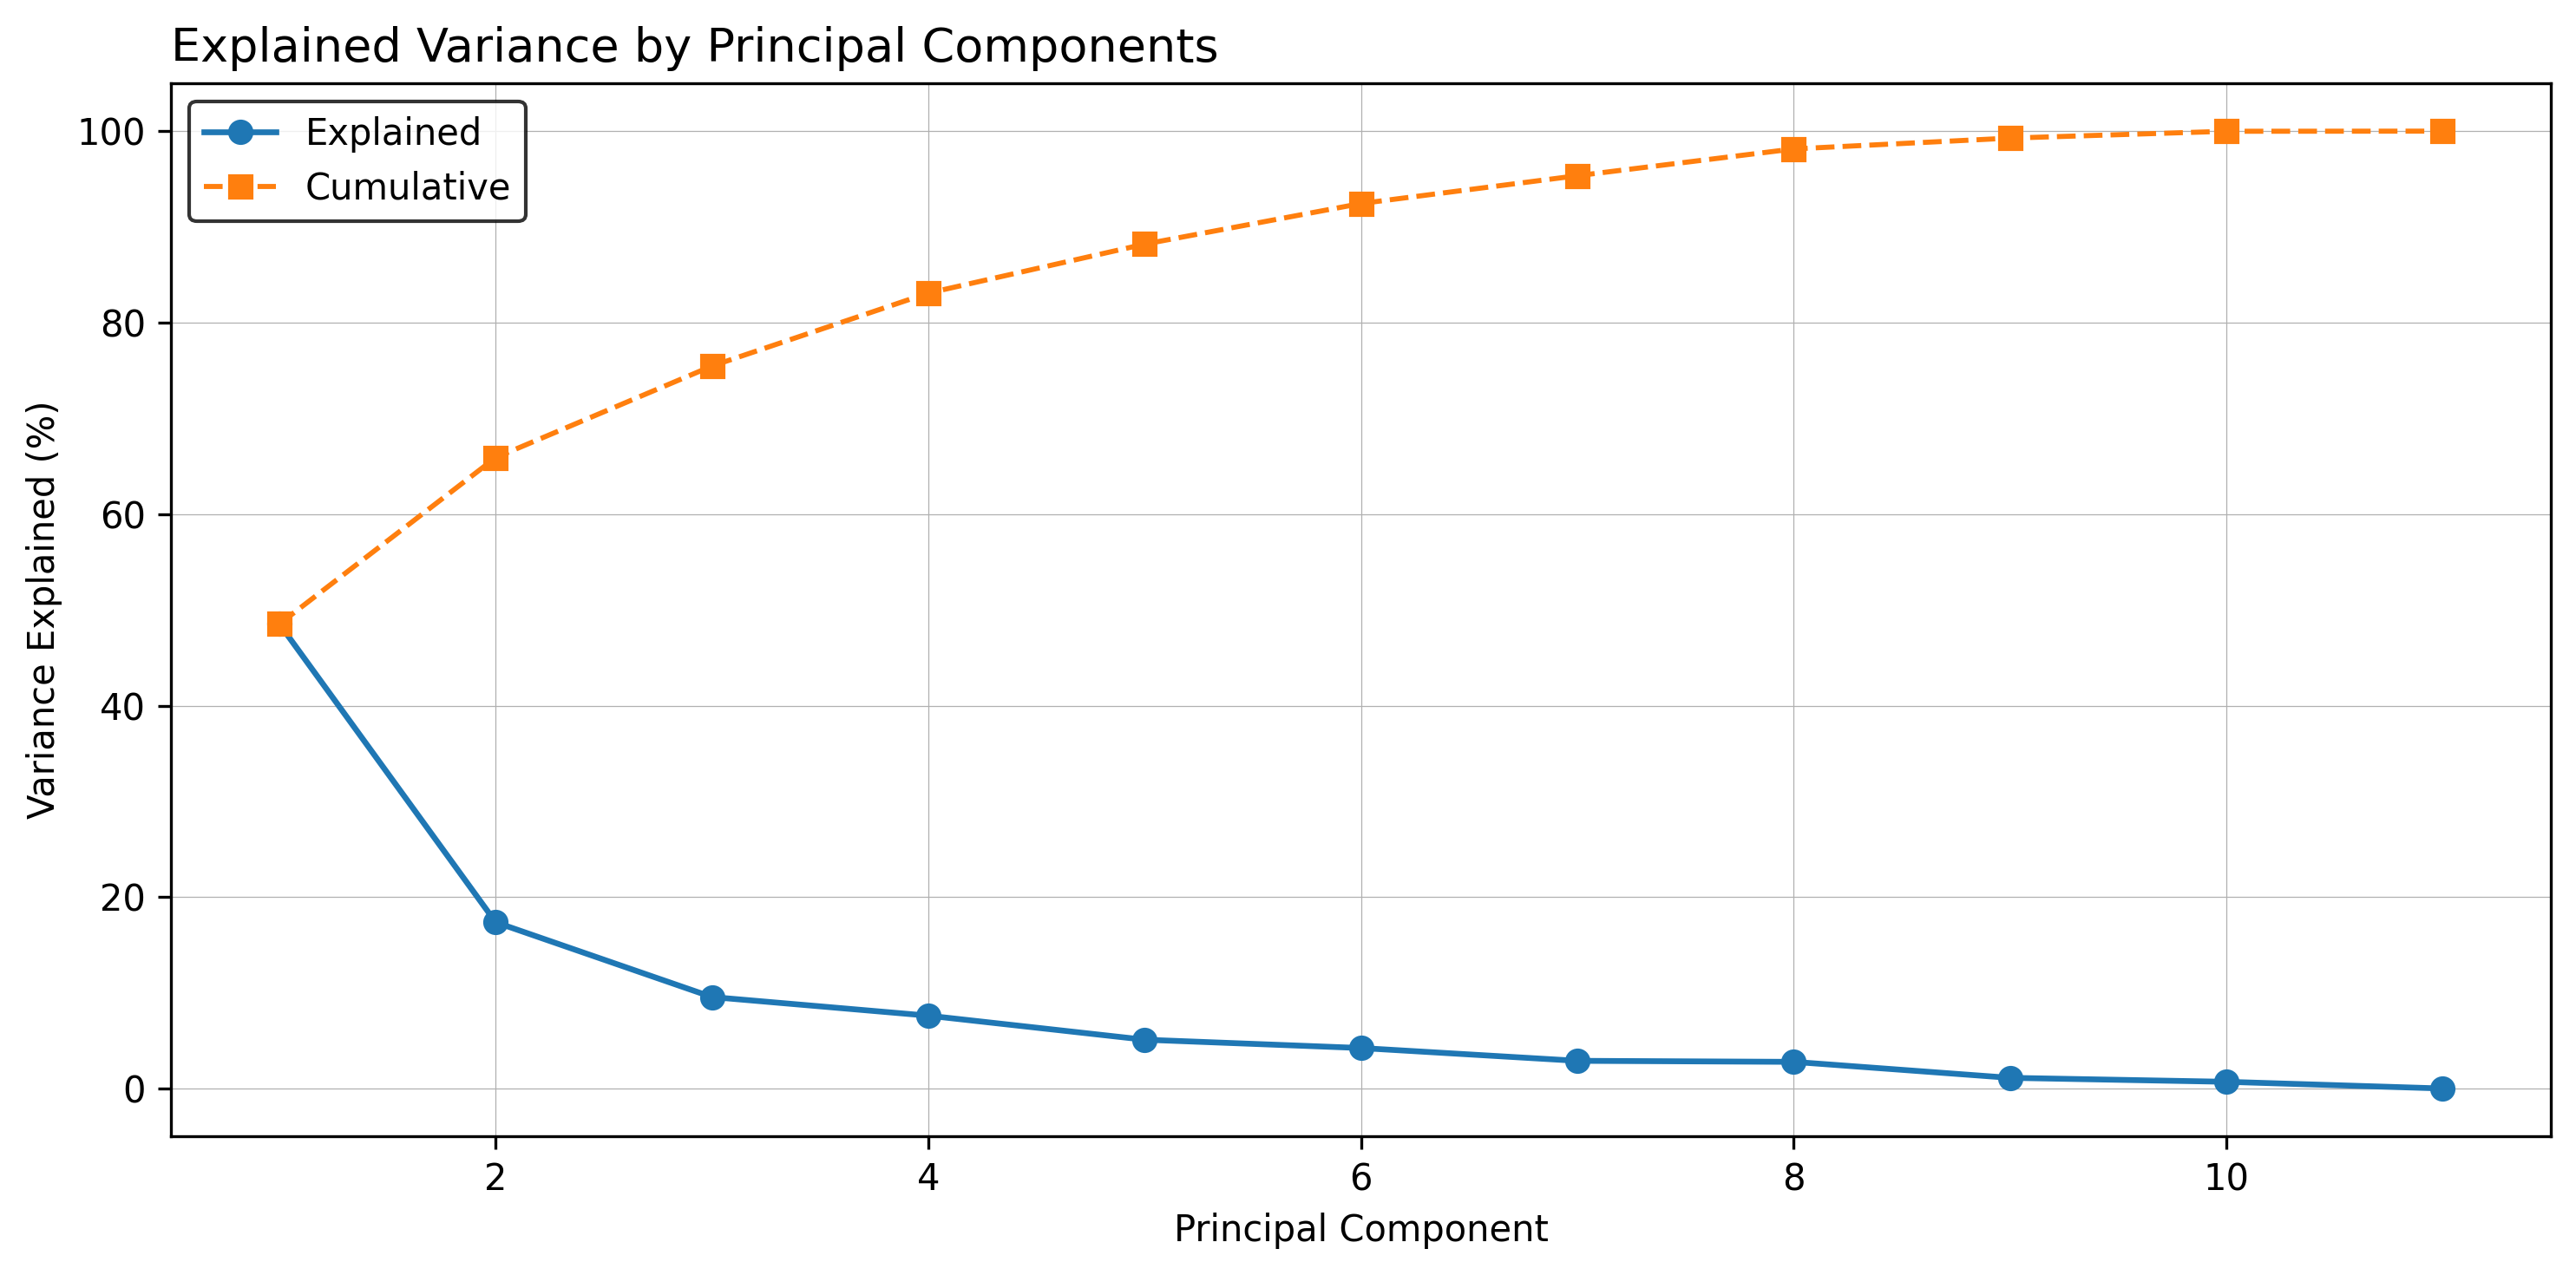

In [24]:
# Plot
plt.figure(figsize=(10, 5), dpi=300)
plt.plot(np.arange(1, len(explained_variance)+1), explained_variance, marker="o", label="Explained", linewidth=1.6)
plt.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance, marker="s", linestyle="--", label="Cumulative", linewidth=1.4)

plt.title("Explained Variance by Principal Components", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.grid(True, linewidth=0.3)
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()

In [81]:
# Run RiskMetrics Correlation VaR
result_pca_correlation = pv.pca_correlation_var(portfolio_matrix, distribution="empirical", confidence_level=confidence_level, n_components=3, window_size=20) # <----- Can choose normal here!

# ES RiskMetrics
result_pca_correlation = pv.correlation_es(result_pca_correlation, confidence_level=confidence_level)


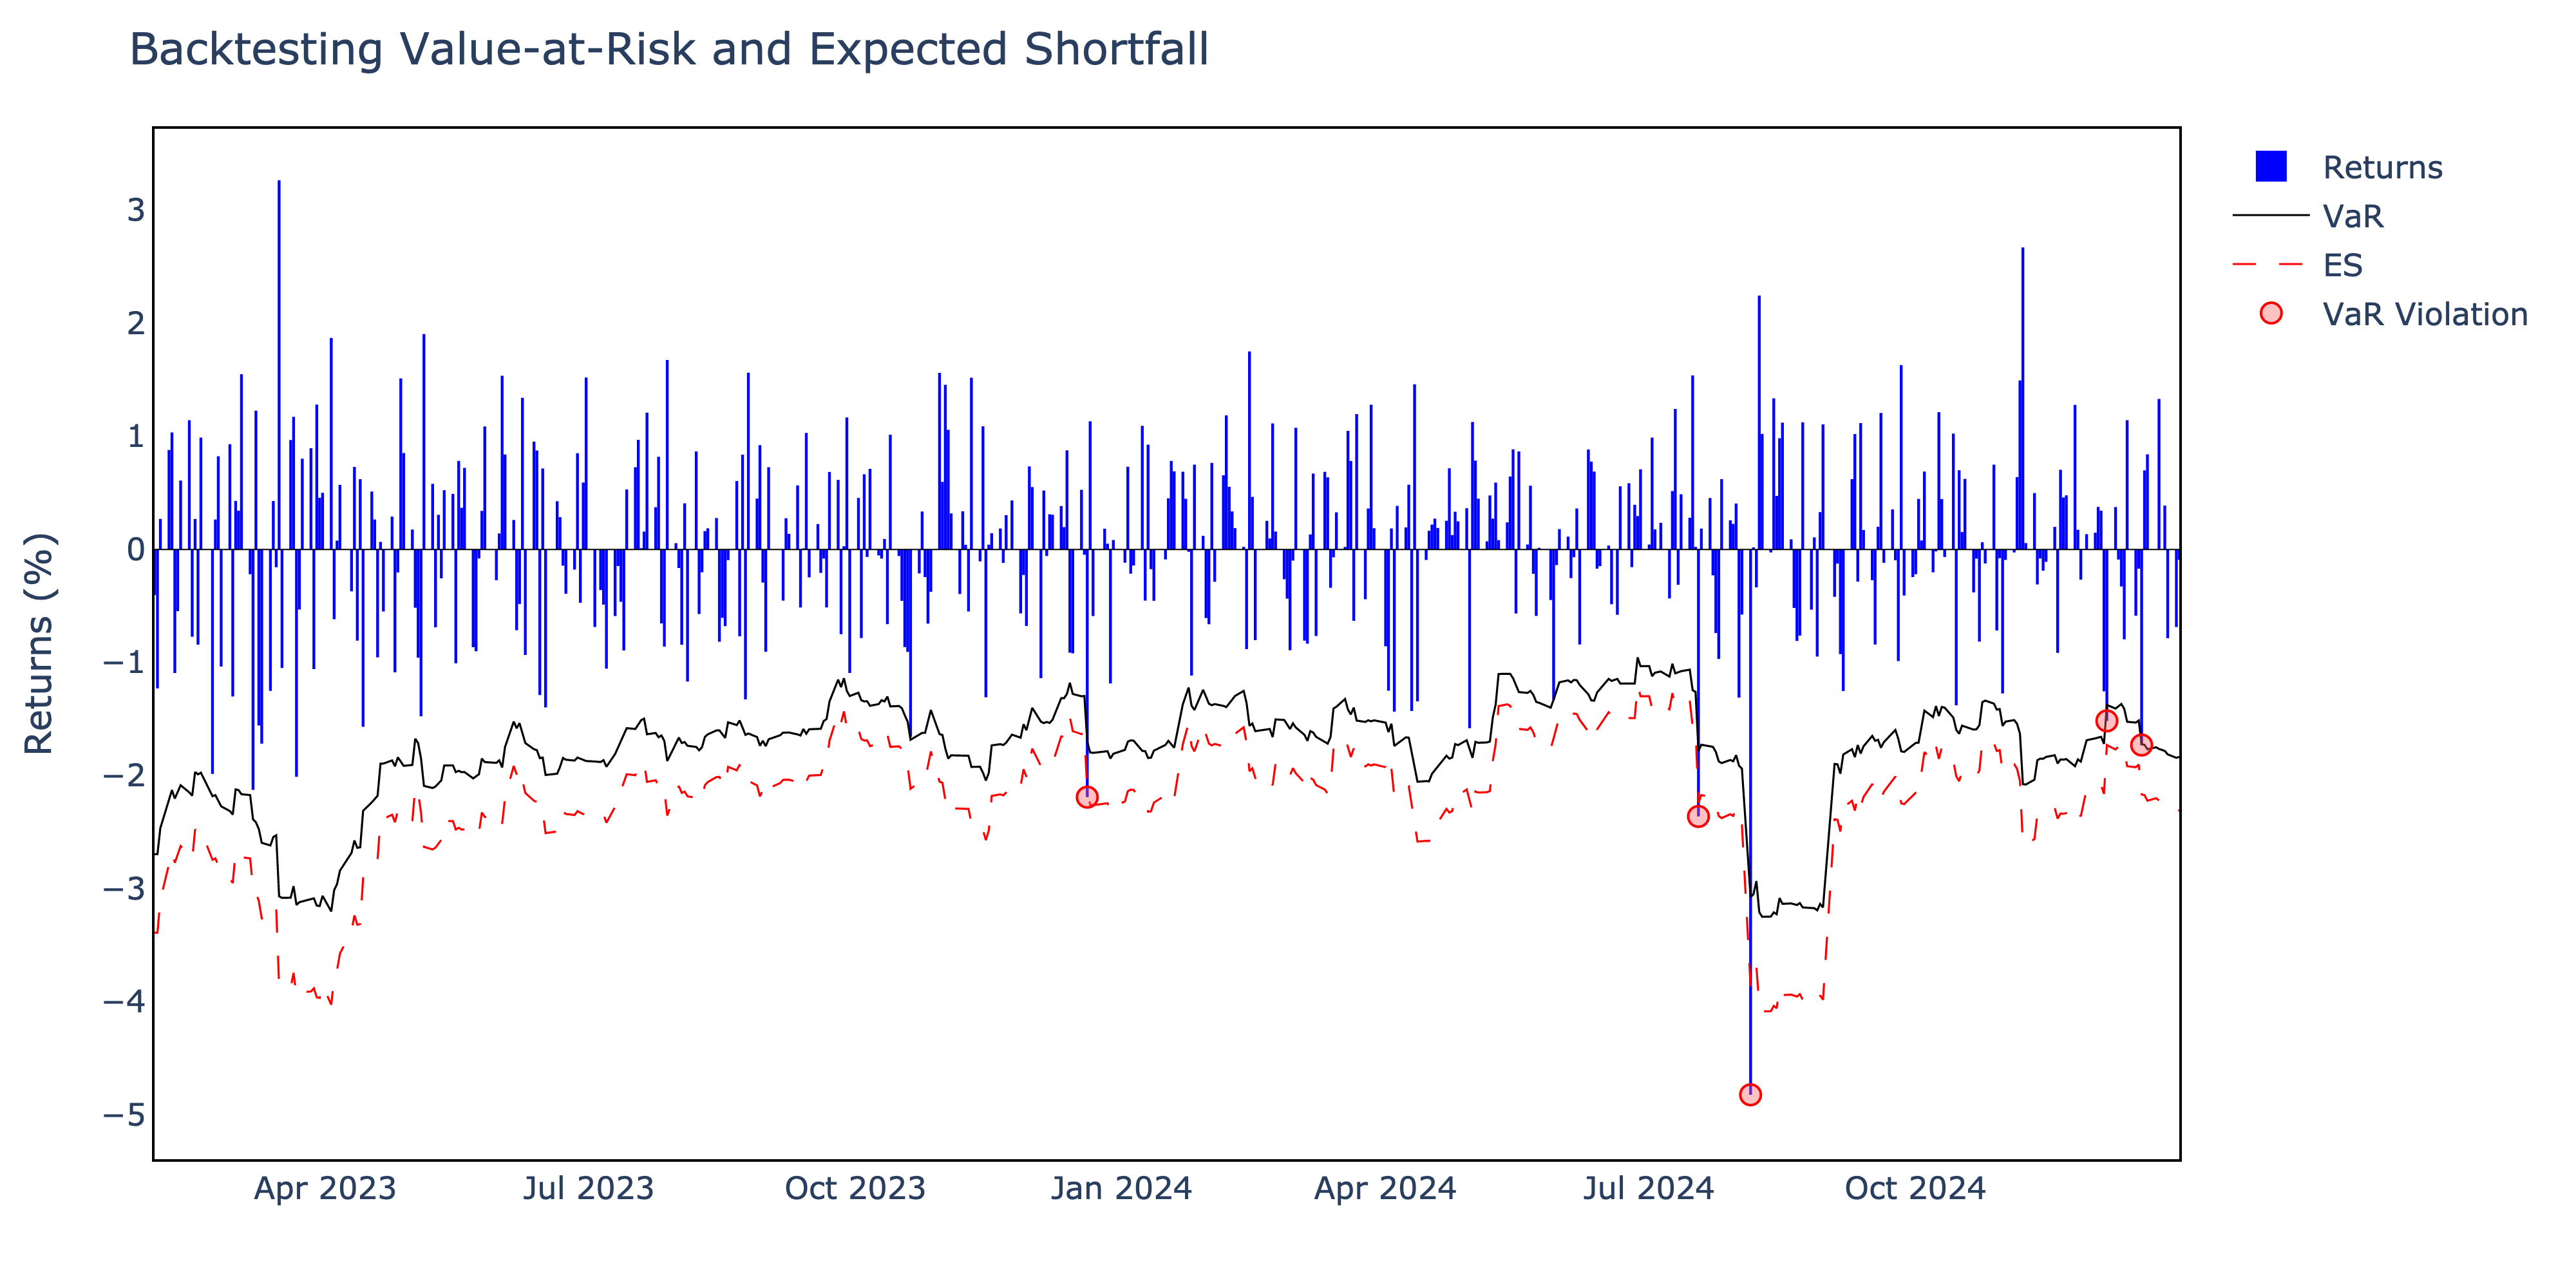

In [82]:
# Plot RiskMetrics model results
pv.plot_backtest(result_pca_correlation, interactive=False)


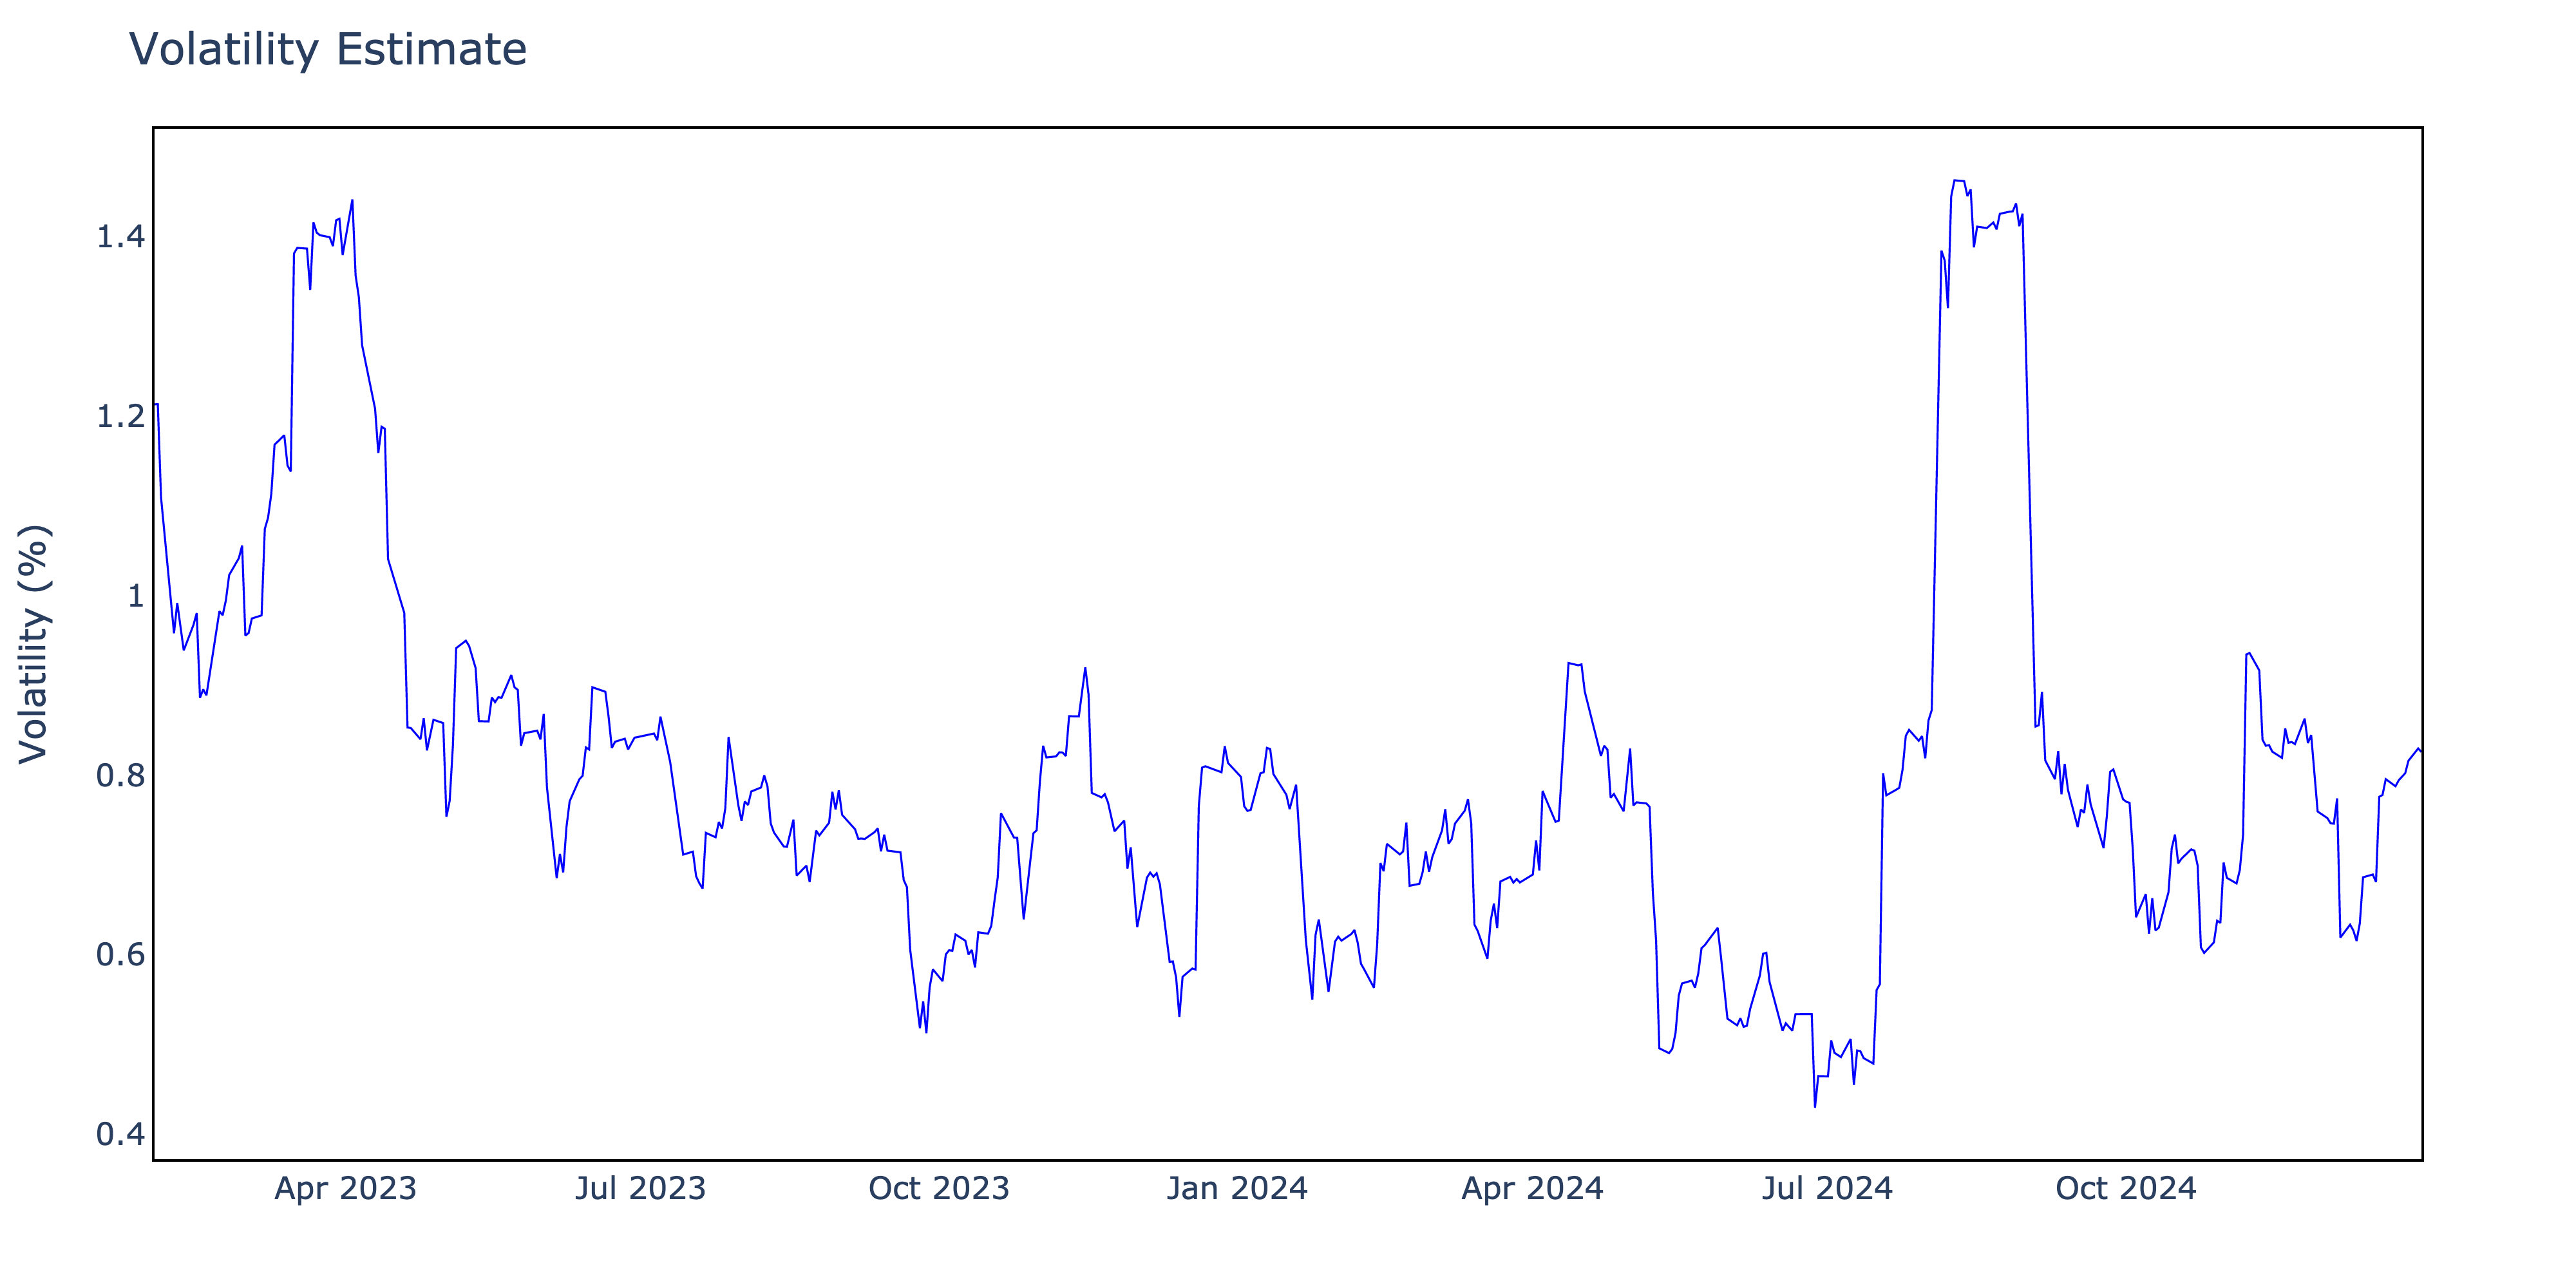

In [83]:
# Plot portfolio volatility 
pv.plot_volatility(result_pca_correlation["Volatility"], interactive=False)

#### Backtesting PCA

In [84]:
# Count violations
pca_corr_violations, pca_corr_violation_rate = pv.count_violations(result_pca_correlation)

# Kupiec Test (Unconditional Coverage)
pca_corr_kupiec = pv.kupiec_test(
    total_violations=pca_corr_violations,
    total_days=len(result_pca_correlation),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
pca_corr_christoffersen = pv.christoffersen_test(result_pca_correlation)

# Joint Test (Conditional Coverage)
pca_corr_joint = pv.joint_lr_test(
    LR_uc=pca_corr_kupiec["LR_uc"],
    LR_c=pca_corr_christoffersen["LR_c"]
)

In [85]:
# Summary output
print(f"\n--- PCA Correlation VaR Backtesting Summary ---")
print(f"Total Violations     : {pca_corr_violations}")
print(f"Violation Rate       : {pca_corr_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {pca_corr_kupiec['LR_uc']:.4f}")
print(f"p-value             : {pca_corr_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {pca_corr_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {pca_corr_christoffersen['LR_c']:.4f}")
print(f"p-value             : {pca_corr_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {pca_corr_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {pca_corr_joint['LR_total']:.4f}")
print(f"p-value             : {pca_corr_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {pca_corr_joint['reject_null']}")


--- PCA Correlation VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.04%

Kupiec Test (UC):
LR_uc               : 0.0067
p-value             : 0.9347
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1050
p-value             : 0.7459
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1118
p-value             : 0.9457
Reject Null (5%)    : False


---

### Ledoit-Wolf Shrinkage Correlation 

This method applies the **Ledoit-Wolf shrinkage estimator** to the portfolio covariance matrix using a rolling window. It reduces estimation error by shrinking the noisy sample covariance matrix toward a structured target:

$$
\Sigma_t = \delta F + (1 - \delta) S_t
$$

Where:
- $S_t$ is the sample covariance from recent returns,
- $F$ is the shrinkage target (often the identity matrix scaled by average variance),
- $\delta$ is the shrinkage intensity, estimated to minimize mean squared error.

The resulting **denoised covariance matrix** is used to compute conditional volatility and Value-at-Risk.

This method is especially effective when the number of assets is large relative to the sample size, a common issue in real-world portfolios. Unlike PCA, **Ledoit-Wolf is fully data-driven** — no manual component selection is needed. The shrinkage intensity adapts automatically to market conditions.

Both **parametric** and **semi-empirical** VaR estimates are supported, using either the normal quantile or historical innovations. Before applying this model, we illustrate the **evolution of shrinkage intensity over time**, showing how the estimator balances data and structure across different regimes.


In [86]:
# Initialize
shrinkage_values = []
dates = []

# Rolling shrinkage values
for t in range(20, len(portfolio_returns)):
    window_returns = portfolio_returns.iloc[t-20:t]
    lw = LedoitWolf()
    lw.fit(window_returns)
    shrinkage_values.append(lw.shrinkage_)
    dates.append(portfolio_returns.index[t])

In [87]:
# Convert to NumPy array
shrinkage_array = np.array(shrinkage_values)

# Print summary stats
print("Ledoit-Wolf Shrinkage Summary:")
print(f"Mean       : {shrinkage_array.mean():.4f}")
print(f"Median     : {np.median(shrinkage_array):.4f}")
print(f"Min        : {shrinkage_array.min():.4f}")
print(f"Max        : {shrinkage_array.max():.4f}")
print(f"Std Dev    : {shrinkage_array.std():.4f}")

Ledoit-Wolf Shrinkage Summary:
Mean       : 0.3112
Median     : 0.2921
Min        : 0.0733
Max        : 0.6038
Std Dev    : 0.1238


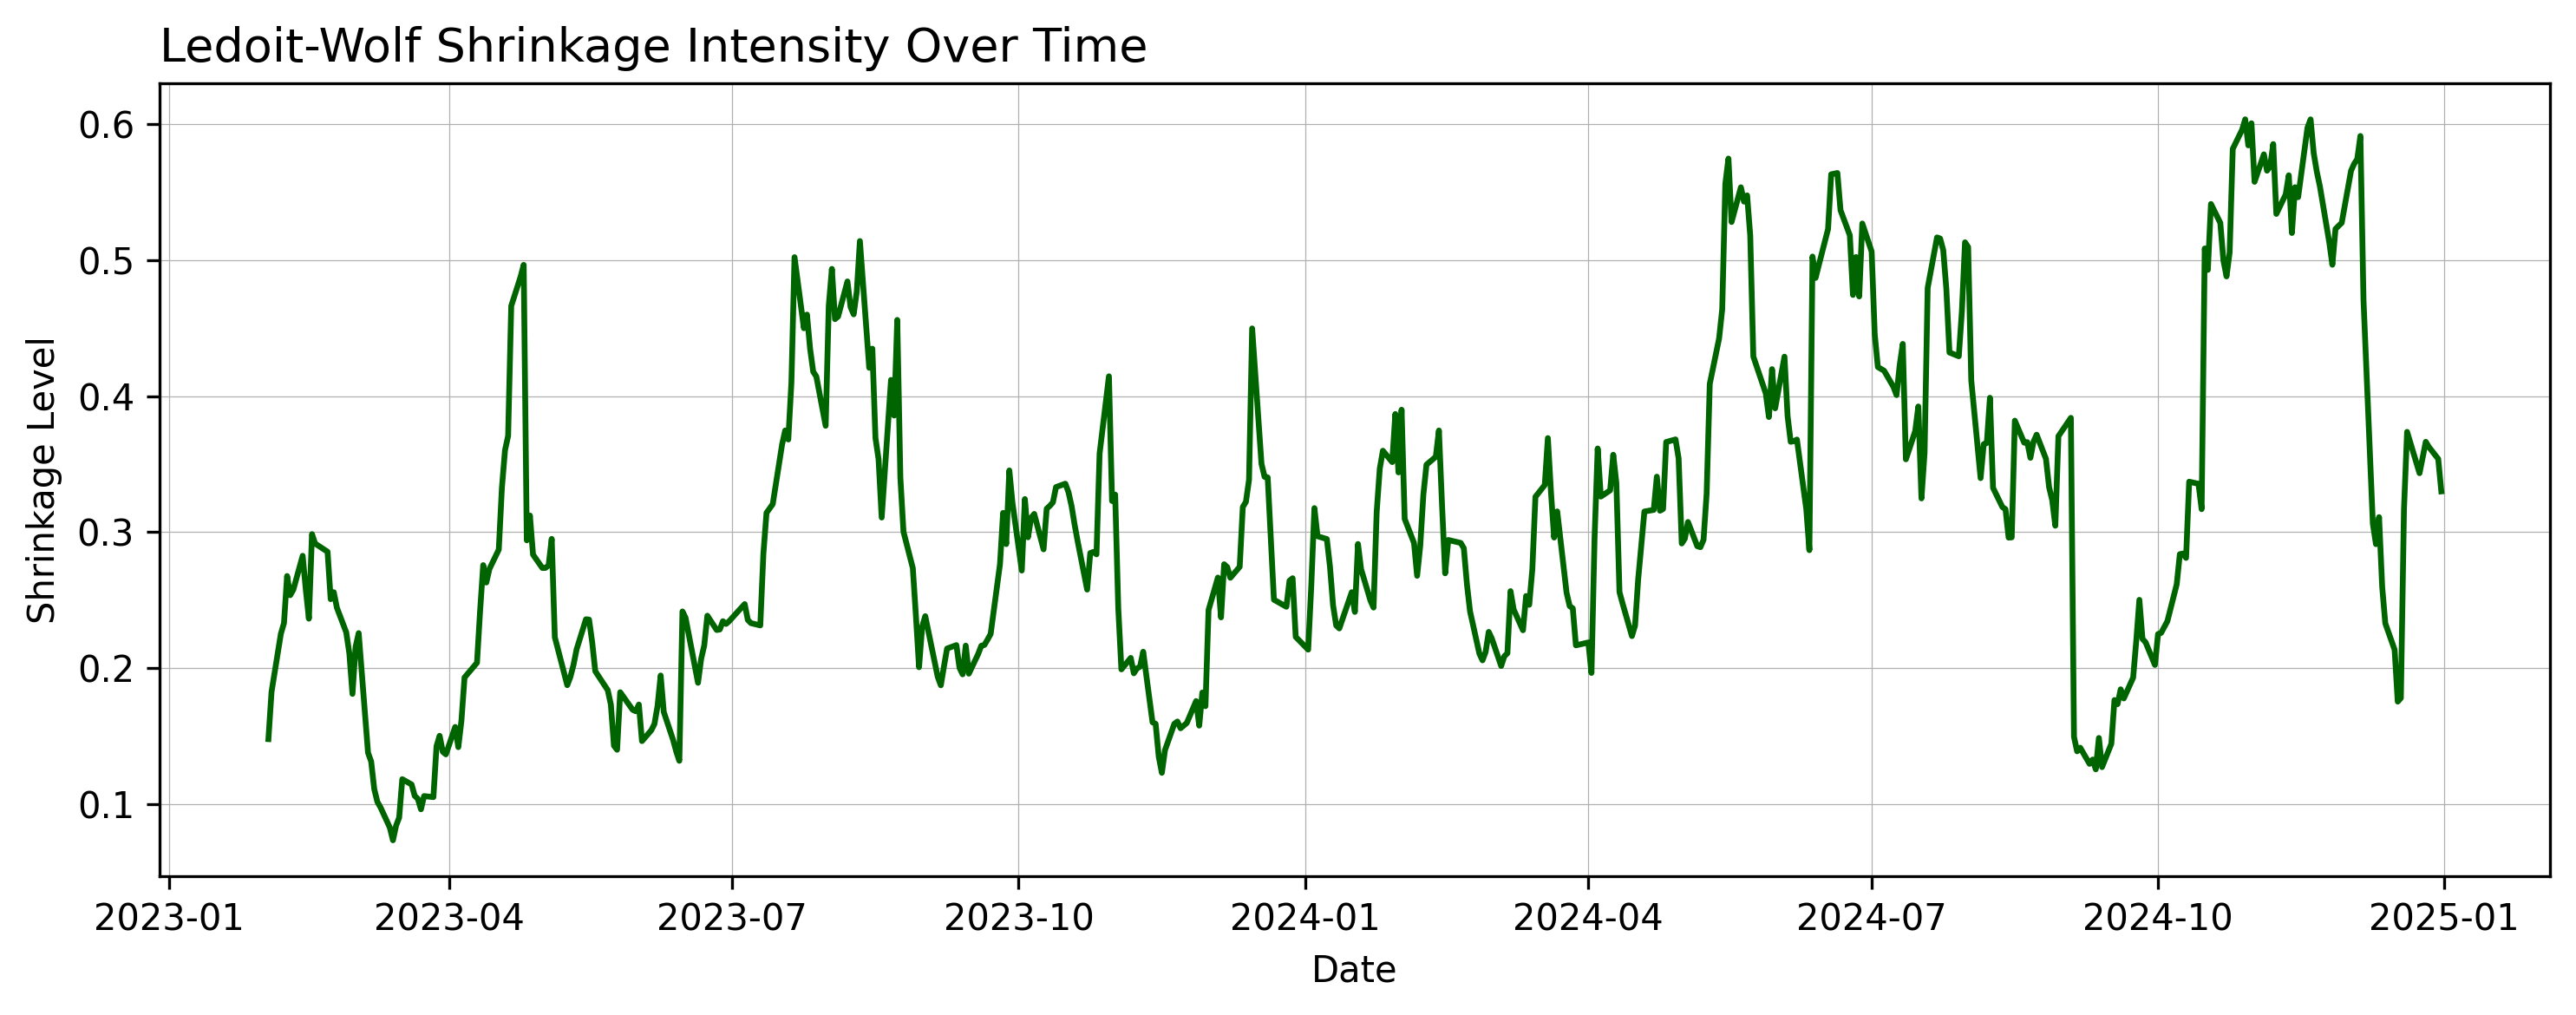

In [88]:
# Plot shrinkage intensity
plt.figure(figsize=(10, 4), dpi=300)
plt.plot(dates, shrinkage_values, label="Shrinkage Intensity", color="darkgreen", linewidth=1.6)
plt.title("Ledoit-Wolf Shrinkage Intensity Over Time", fontsize=13, loc="left", fontweight="medium")
plt.xlabel("Date")
plt.ylabel("Shrinkage Level")
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

In [89]:
# Run RiskMetrics Correlation VaR
result_lw_correlation = pv.lw_correlation_var(portfolio_matrix, distribution="empirical", confidence_level=confidence_level, window_size=20) # <----- Can choose normal here!

# ES RiskMetrics
result_lw_correlation = pv.correlation_es(result_lw_correlation, confidence_level=confidence_level)


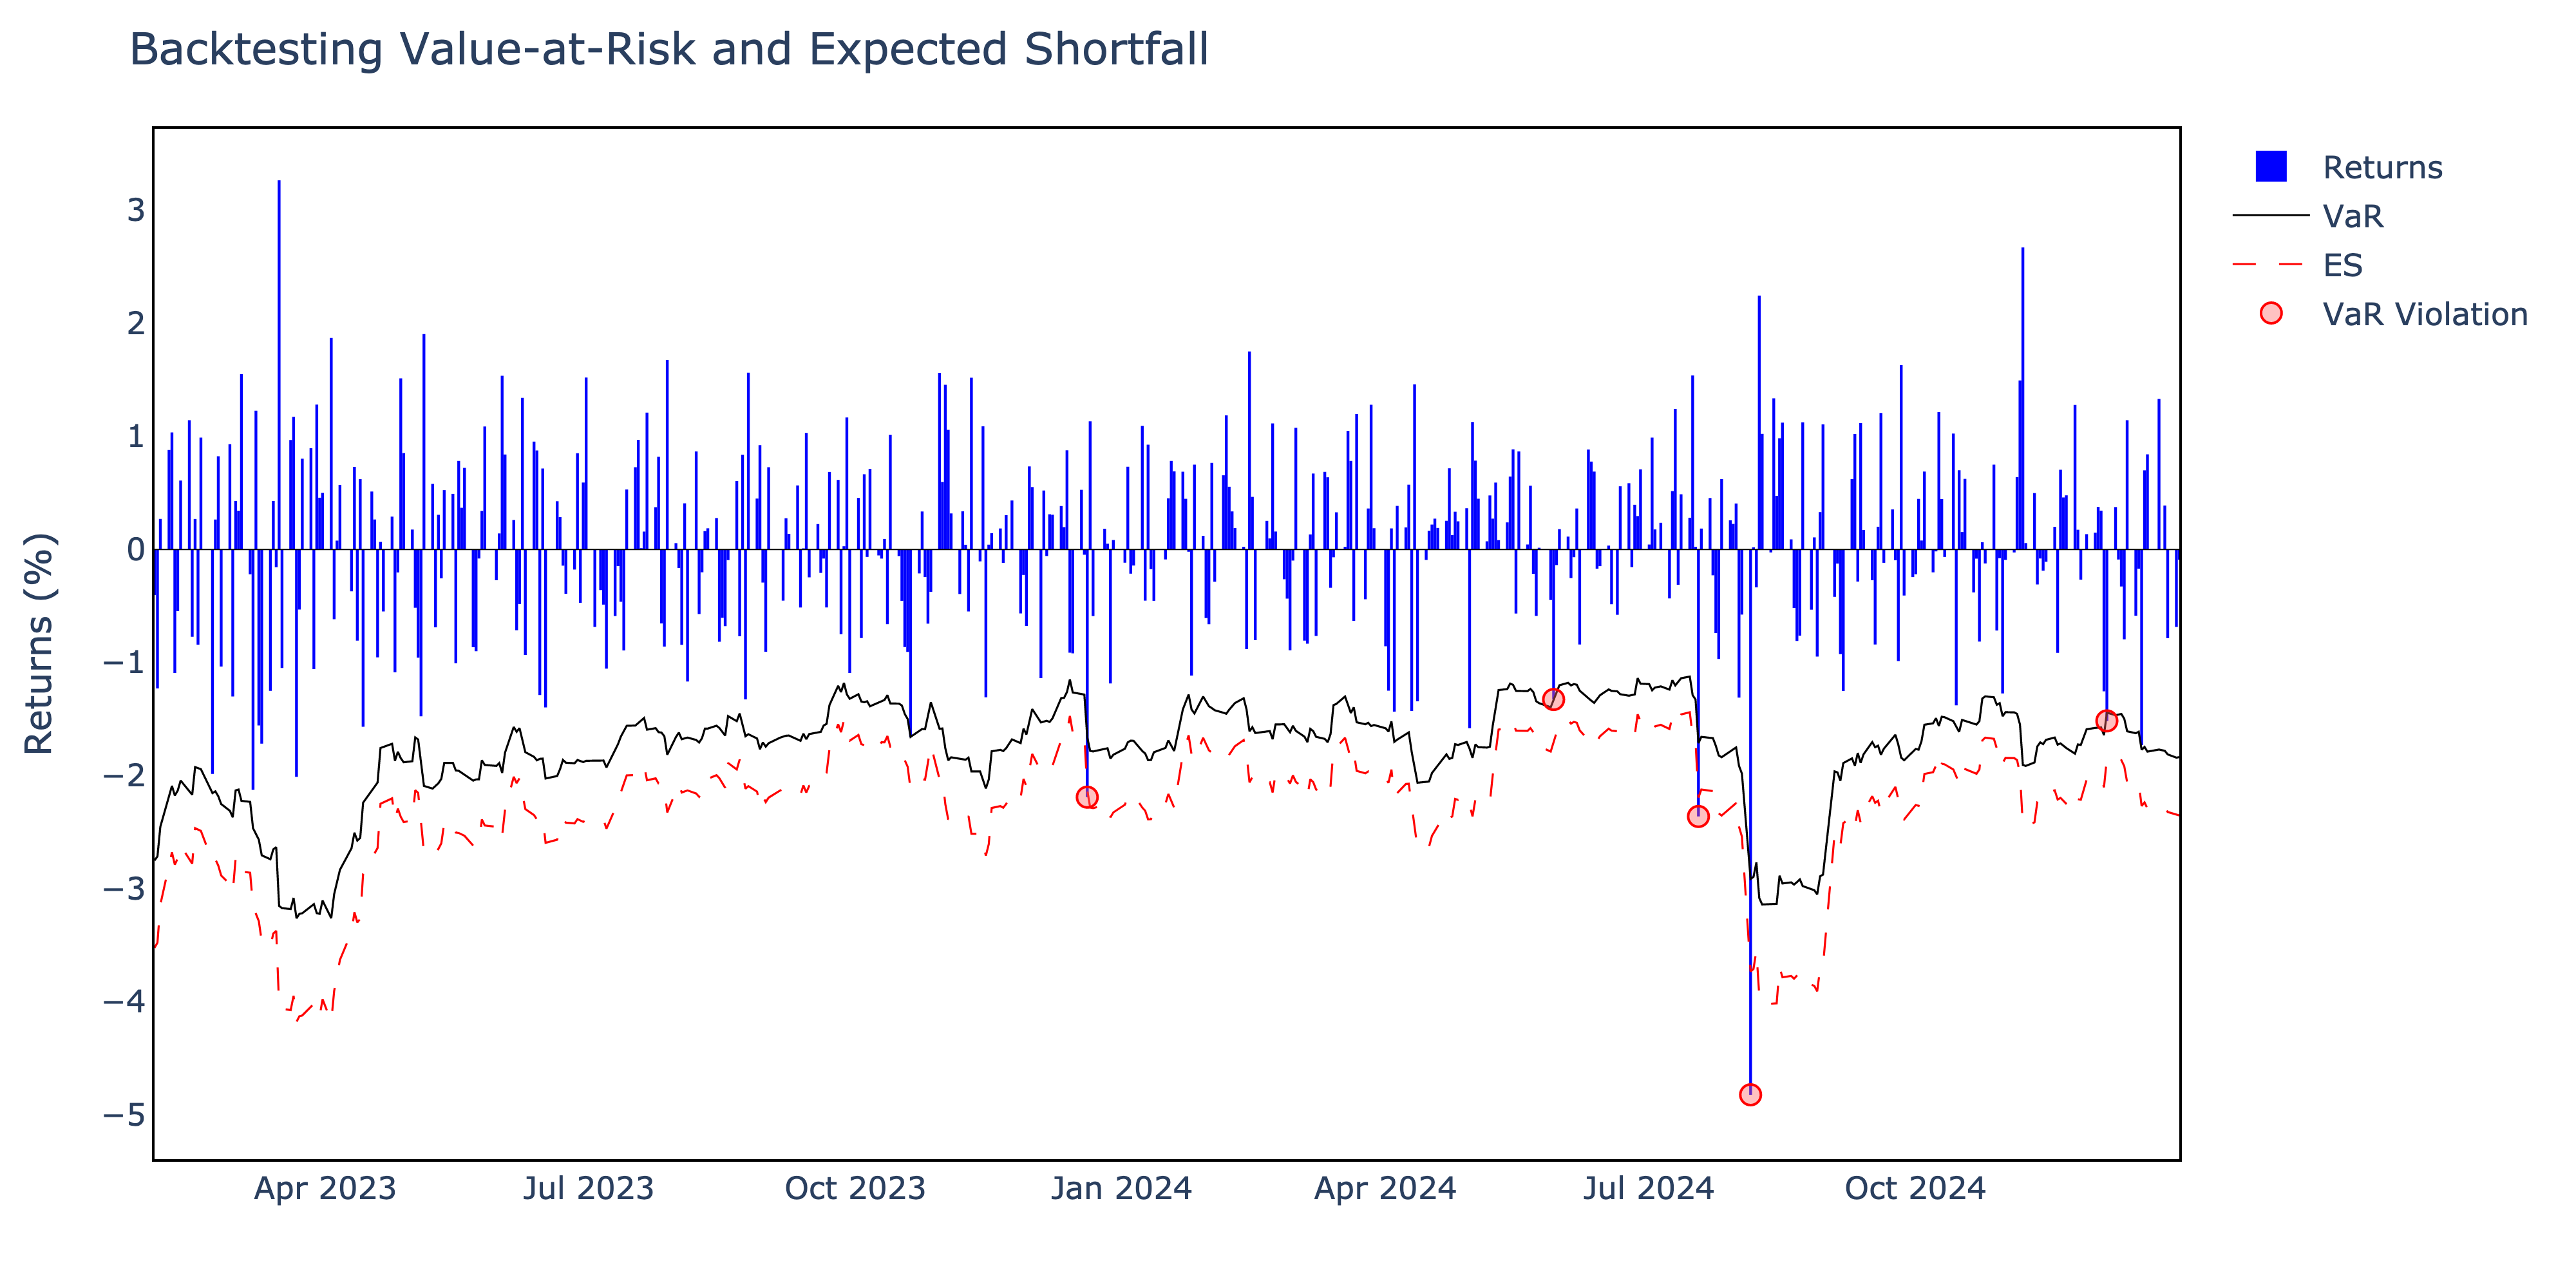

In [90]:
# Plot RiskMetrics model results
pv.plot_backtest(result_lw_correlation, interactive=False)


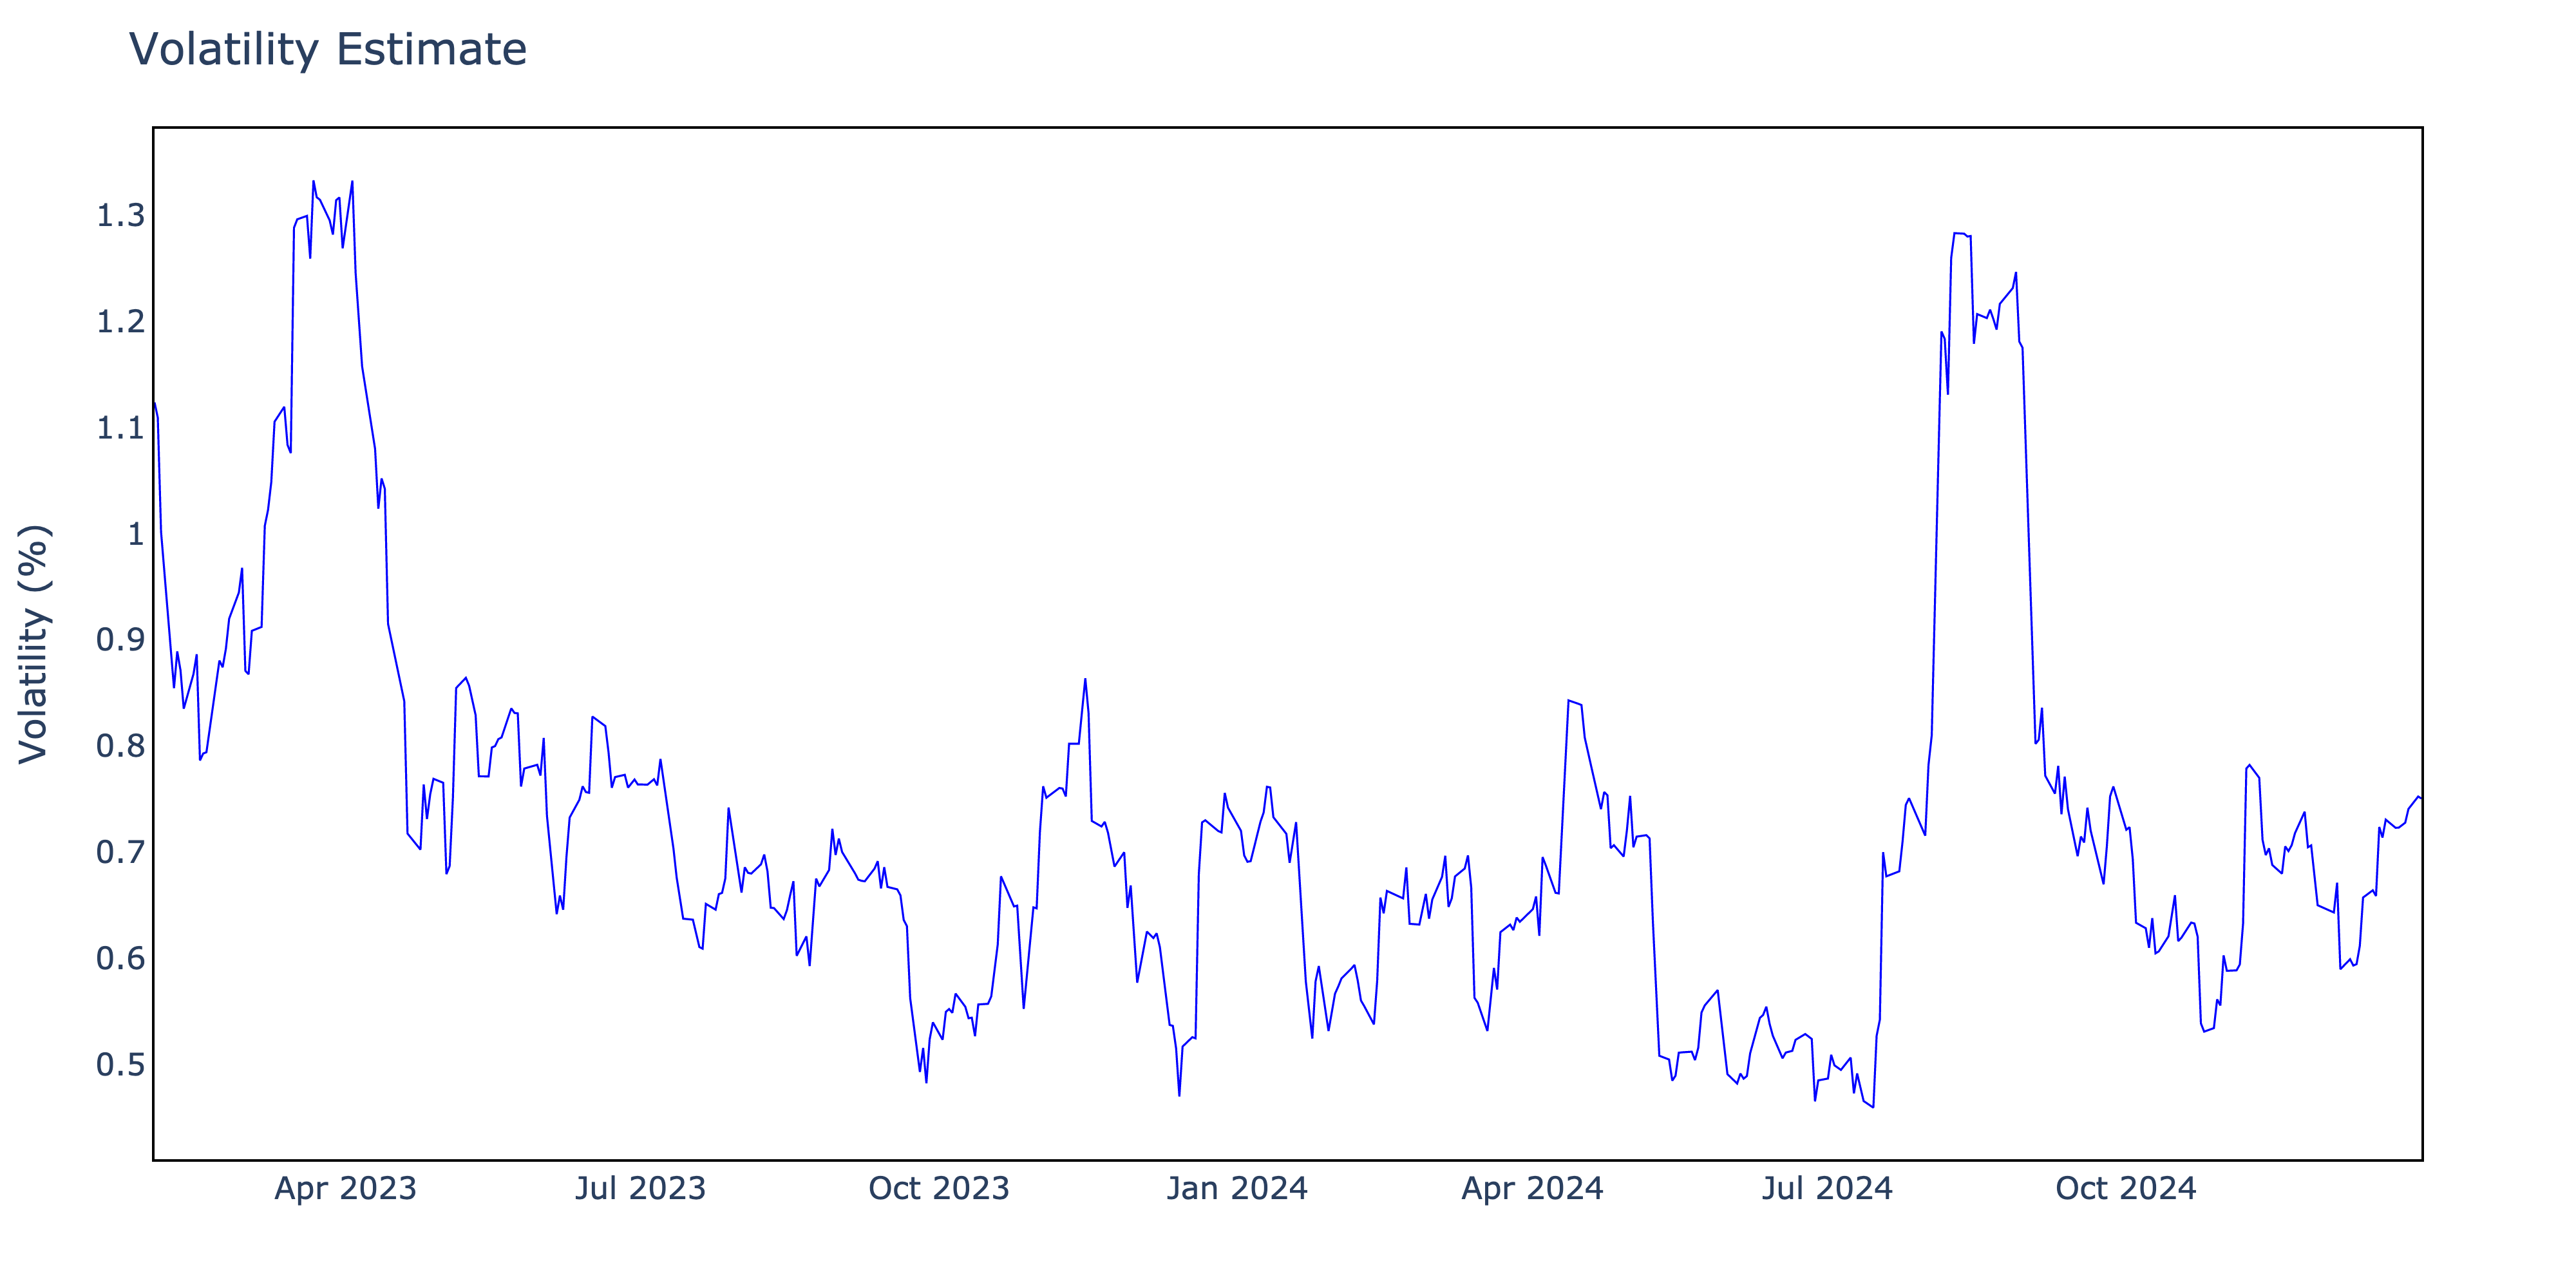

In [91]:
# Plot portfolio volatility 
pv.plot_volatility(result_lw_correlation["Volatility"], interactive=False)

#### Backtesting LW

In [92]:
# Count violations
lw_corr_violations, lw_corr_violation_rate = pv.count_violations(result_lw_correlation)

# Kupiec Test (Unconditional Coverage)
lw_corr_kupiec = pv.kupiec_test(
    total_violations=lw_corr_violations,
    total_days=len(result_lw_correlation),
    confidence_level=confidence_level
)

# Christoffersen Test (Independence)
lw_corr_christoffersen = pv.christoffersen_test(result_lw_correlation)

# Joint Test (Conditional Coverage)
lw_corr_joint = pv.joint_lr_test(
    LR_uc=lw_corr_kupiec["LR_uc"],
    LR_c=lw_corr_christoffersen["LR_c"]
)

In [93]:
# Summary output
print(f"\n--- Ledoit-Wolf Correlation VaR Backtesting Summary ---")
print(f"Total Violations     : {lw_corr_violations}")
print(f"Violation Rate       : {lw_corr_violation_rate * 100:.2f}%\n")

print("Kupiec Test (UC):")
print(f"LR_uc               : {lw_corr_kupiec['LR_uc']:.4f}")
print(f"p-value             : {lw_corr_kupiec['p_value']:.4f}")
print(f"Reject Null (5%)    : {lw_corr_kupiec['reject_null']}")

print("\nChristoffersen Test (Independence):")
print(f"LR_c                : {lw_corr_christoffersen['LR_c']:.4f}")
print(f"p-value             : {lw_corr_christoffersen['p_value']:.4f}")
print(f"Reject Null (5%)    : {lw_corr_christoffersen['reject_null']}")

print("\nJoint Test (Conditional Coverage):")
print(f"LR_total            : {lw_corr_joint['LR_total']:.4f}")
print(f"p-value             : {lw_corr_joint['p_value']:.4f}")
print(f"Reject Null (5%)    : {lw_corr_joint['reject_null']}")


--- Ledoit-Wolf Correlation VaR Backtesting Summary ---
Total Violations     : 5
Violation Rate       : 1.04%

Kupiec Test (UC):
LR_uc               : 0.0067
p-value             : 0.9347
Reject Null (5%)    : False

Christoffersen Test (Independence):
LR_c                : 0.1050
p-value             : 0.7459
Reject Null (5%)    : False

Joint Test (Conditional Coverage):
LR_total            : 0.1118
p-value             : 0.9457
Reject Null (5%)    : False


#### Portfolio Volatility Comparison

We conclude with a simple comparison of the four correlation-based methods introduced: MA, EWMA, PCA, and Ledoit-Wolf. This highlights how different approaches to estimating the covariance matrix affect portfolio volatility estimation.

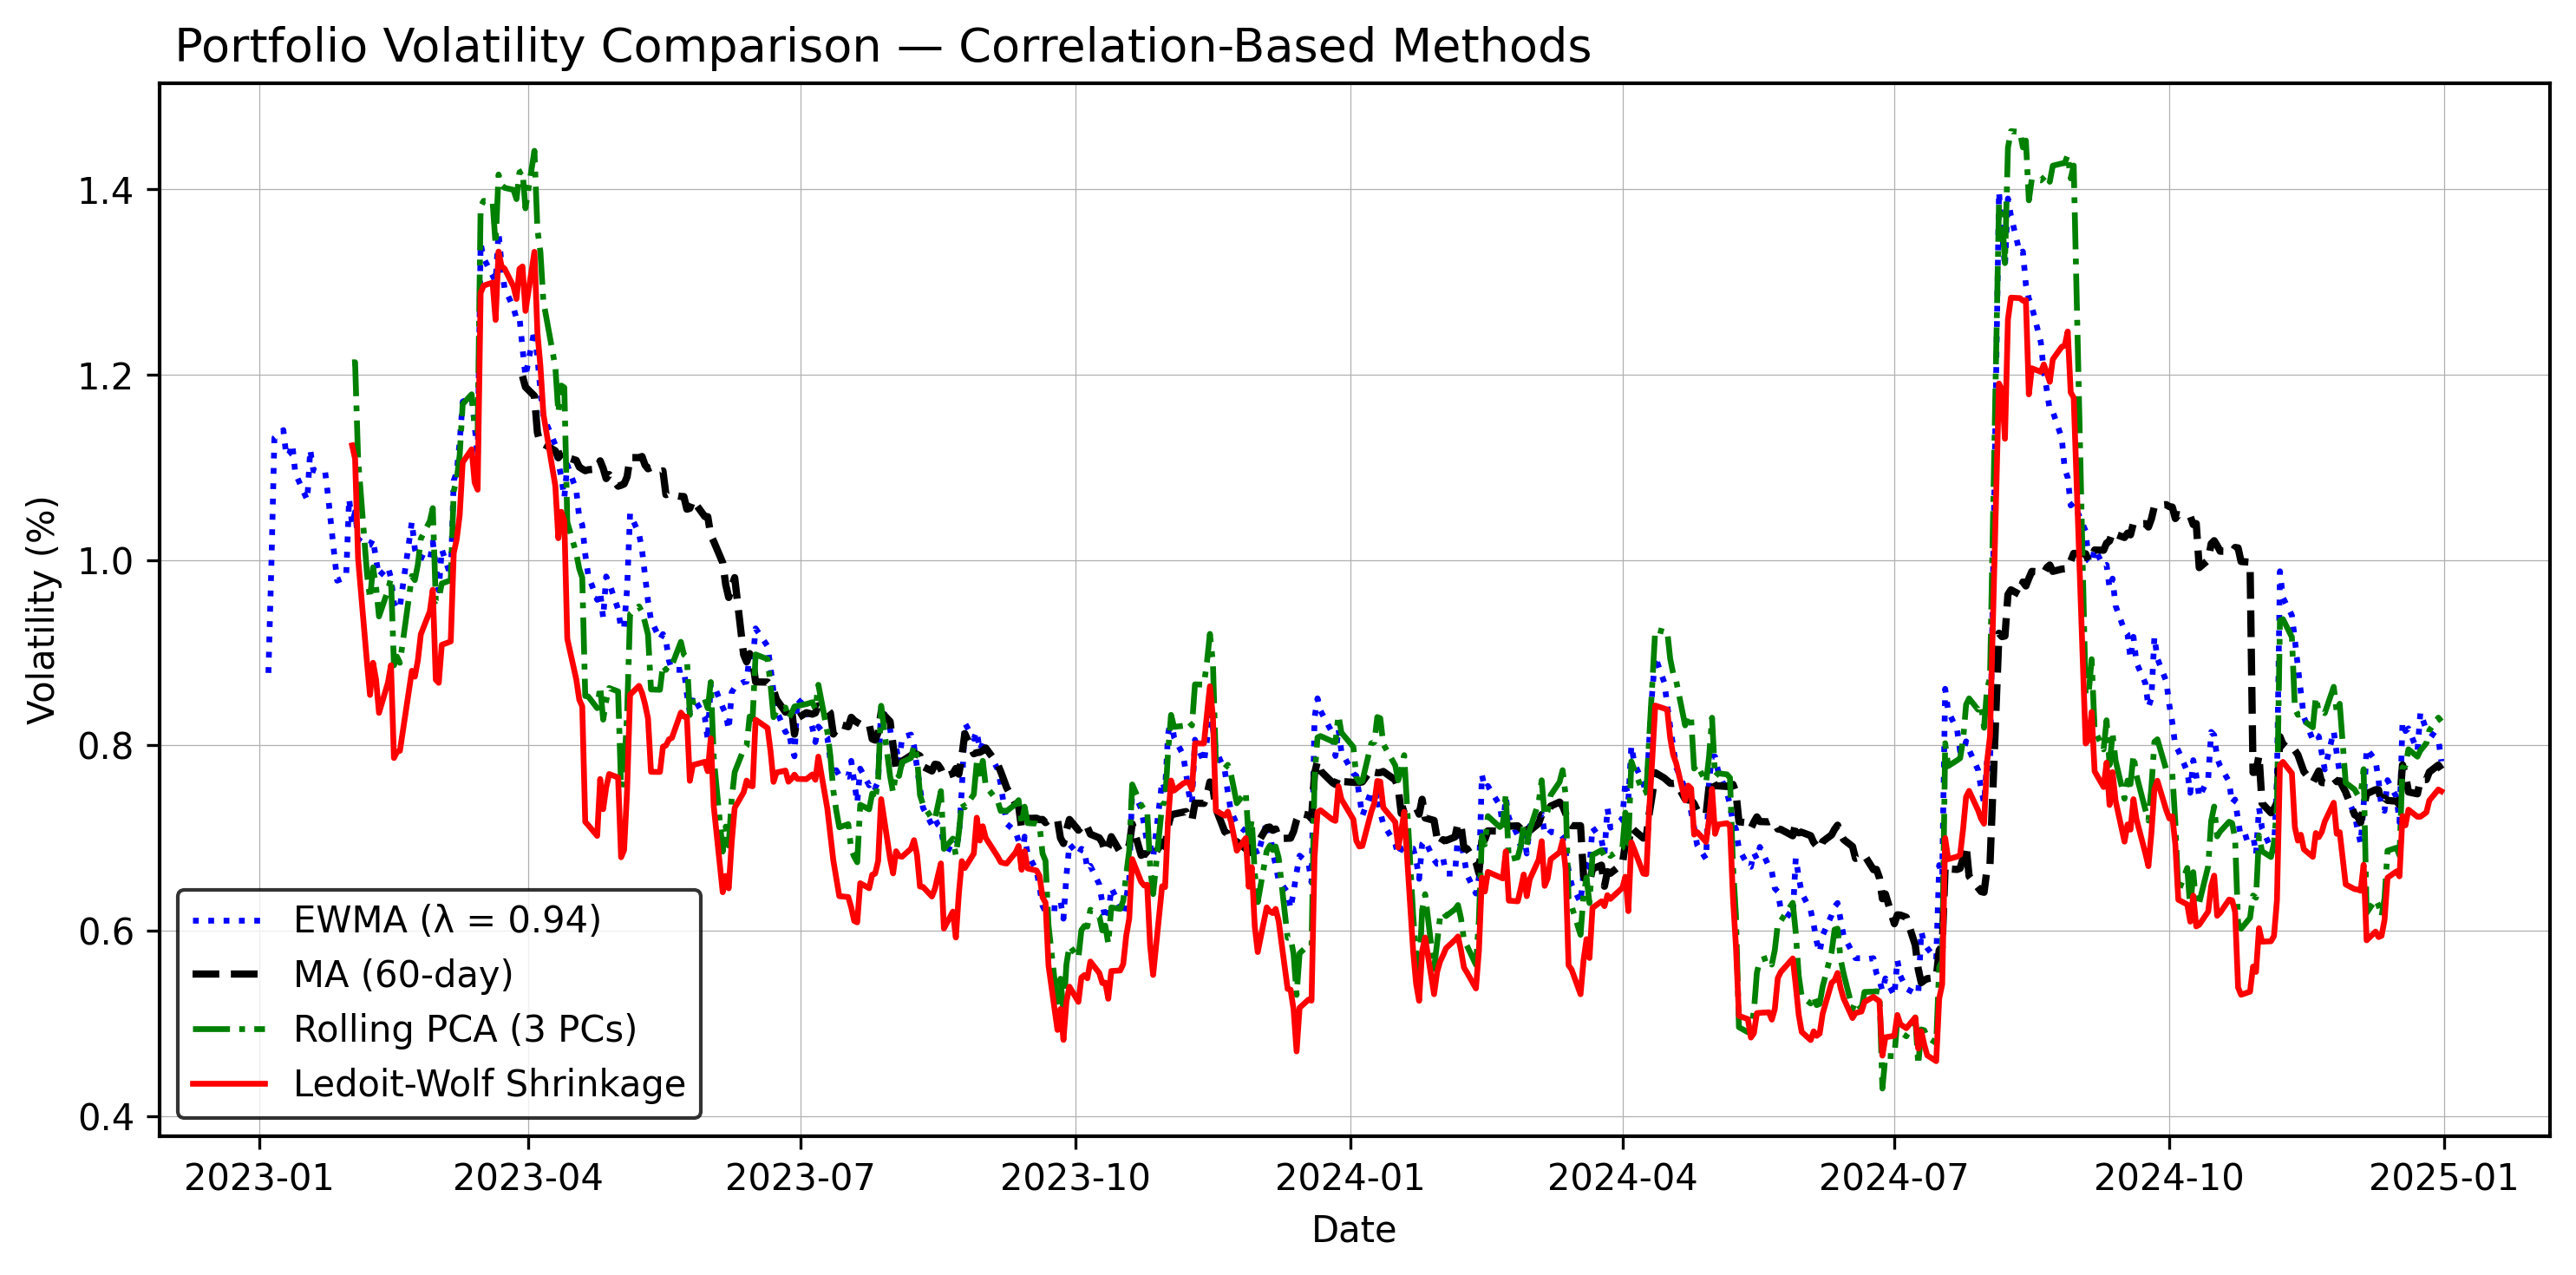

In [94]:
# Prepare the volatility DataFrame
volatility_data = pd.DataFrame({
    "EWMA": result_ewma_correlation["Volatility"] * 100,
    "MA": result_ma_correlation["Volatility"] * 100,
    "PCA": result_pca_correlation["Volatility"] * 100,
    "Ledoit-Wolf": result_lw_correlation["Volatility"] * 100
})

plt.figure(figsize=(10, 5), dpi=300)

# Line styles and plotting
plt.plot(volatility_data.index, volatility_data["EWMA"], label="EWMA (λ = 0.94)",
         color="blue", linestyle=":", linewidth=1.6)

plt.plot(volatility_data.index, volatility_data["MA"], label="MA (60-day)",
         color="black", linestyle="--", linewidth=2.0)

plt.plot(volatility_data.index, volatility_data["PCA"], label="Rolling PCA (3 PCs)",
         color="green", linestyle="-.", linewidth=1.6)

plt.plot(volatility_data.index, volatility_data["Ledoit-Wolf"], label="Ledoit-Wolf Shrinkage",
         color="red", linestyle="-", linewidth=1.6)

# Titles and labels
plt.title(" Portfolio Volatility Comparison — Correlation-Based Methods", loc="left", fontsize=13, fontweight="medium")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

# Axes styling
ax = plt.gca()
for side in ["top", "bottom", "left", "right"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_color("black")
    ax.spines[side].set_linewidth(1)

ax.tick_params(width=0.8, color='black')
plt.grid(True, linewidth=0.3)

# Legend
plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()
plt.show()
